# Demo: Mapping Luhman 16B with NIRSpec

In this tutorial, we will demonstrate how to use `spectralmap` to analyze time-series observations. We will use a sequence of NIRSpec observations of the brown dwarf Luhman 16B to recover a spectroscopic map of its surface.

**We will cover:**
1. Loading and preprocessing the lightcurve data.
2. Inverting the lightcurves to obtain surface maps.
3. Clustering the map pixels to identify distinct spectral regions.
4. Extracting and analyzing the spectra of these regions.

Let's get started!

## 1. Load Data
We load the NIRSpec lightcurve files. Each file corresponds to a specific rotation phase (angle). We will read them in, sort them by phase, and normalize the flux.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from spectralmap.utilities import bin_flux_by_theta
from spectralmap.plotting import COLOR_LIST, PAPER_FIGURES_DIR

# 1. Load the 2023 and 2024 data files
file_23 = "data/Luhman16b_NIRSpec_2023.npz"
file_24 = "data/Luhman16b_NIRSpec_2024.npz"

d23 = np.load(file_23)
d24 = np.load(file_24)

theta_23 = np.asarray(d23["theta"])
wl_23 = d23["wl"]
flux_raw_23 = d23["flux_raw"]
flux_err_23 = None

theta_24 = np.asarray(d24["theta"])
wl_24 = d24["wl"]
flux_raw_24 = d24["flux_raw"]
flux_err_24 = d24["flux_err"]

# 2. Estimate phase shift using circular cross-correlation of broadband light curves
lc_23 = np.nanmean(d23["flux_raw"], axis=0)
lc_24 = np.nanmean(d24["flux_raw"], axis=0)

def periodic_interp(theta_deg, values, grid_deg):
    order = np.argsort(theta_deg)
    x = theta_deg[order]
    y = values[order]
    x_ext = np.concatenate([x - 360, x, x + 360])
    y_ext = np.concatenate([y, y, y])
    return np.interp(grid_deg, x_ext, y_ext)

phase_grid = np.linspace(0, 360, 720, endpoint=False)
ref = periodic_interp(theta_23, lc_23, phase_grid)
ref = (ref - np.nanmean(ref)) / np.nanstd(ref)

candidate_shifts = np.linspace(-180, 180, 1441)
corr = np.empty(candidate_shifts.size)

for i, shift_deg in enumerate(candidate_shifts):
    shifted_theta_24 = (theta_24 + shift_deg)
    cur = periodic_interp(shifted_theta_24, lc_24, phase_grid)
    cur = (cur - np.nanmean(cur)) / np.nanstd(cur)
    corr[i] = np.nanmean(ref * cur)

best_shift_deg = float(candidate_shifts[np.nanargmax(corr)])
print(f"Best 2024→2023 phase shift from cross-correlation: {best_shift_deg:.2f} deg")

# 3. Apply inferred shift to 2024 phases
theta_24 = (theta_24 + best_shift_deg)

# 4. Normalize and bin
amplitudes_23 = np.nanmean(flux_raw_23, axis=1)
amplitudes_24 = np.nanmean(flux_raw_24, axis=1)
flux_24 = (flux_raw_24.T / amplitudes_24).T
flux_23 = (flux_raw_23.T / amplitudes_23).T
theta_24, flux_24, flux_err_24, _ = bin_flux_by_theta(theta_24, flux_24, n_bins=64, flux_err=flux_err_24)
theta_23, flux_23, flux_err_23, _ = bin_flux_by_theta(theta_23, flux_23, n_bins=64, flux_err=flux_err_23)

Best 2024→2023 phase shift from cross-correlation: 9.00 deg


## 2. Inversion with SpectralMap

First, we organize the data into a `LightCurveData` object. We must specify the inclination of the object (here assumed to be 80 degrees).

In [7]:
from spectralmap.mapping import LightCurveData, make_map
data_24 = LightCurveData(theta=theta_24, flux=flux_24, flux_err=flux_err_24, inc=90)
data_23 = LightCurveData(theta=theta_23, flux=flux_23, flux_err=flux_err_23, inc=90)

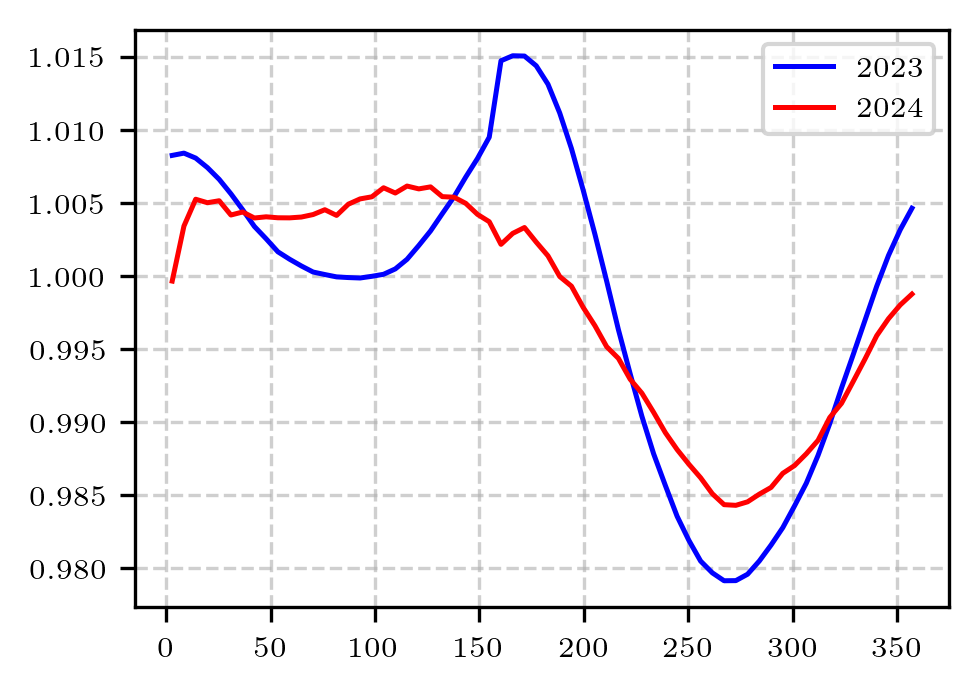

In [8]:
plt.plot(theta_23, np.nanmean(flux_23, axis=0), label="2023", color='blue', linewidth=1.2)
plt.plot(theta_24, np.nanmean(flux_24, axis=0), label="2024", color='red', linewidth=1.2)
plt.legend()

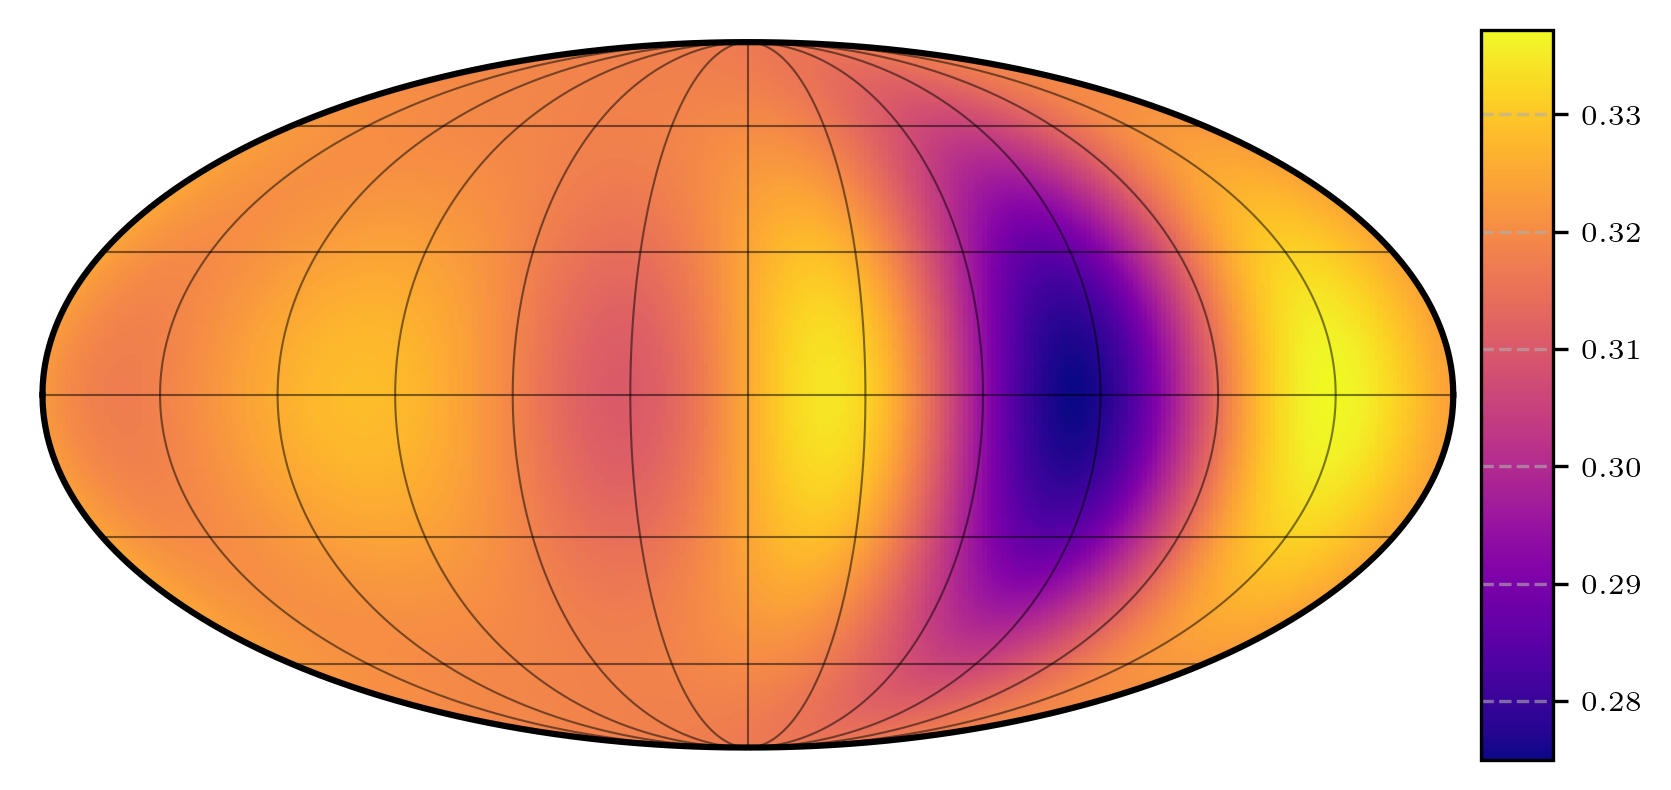

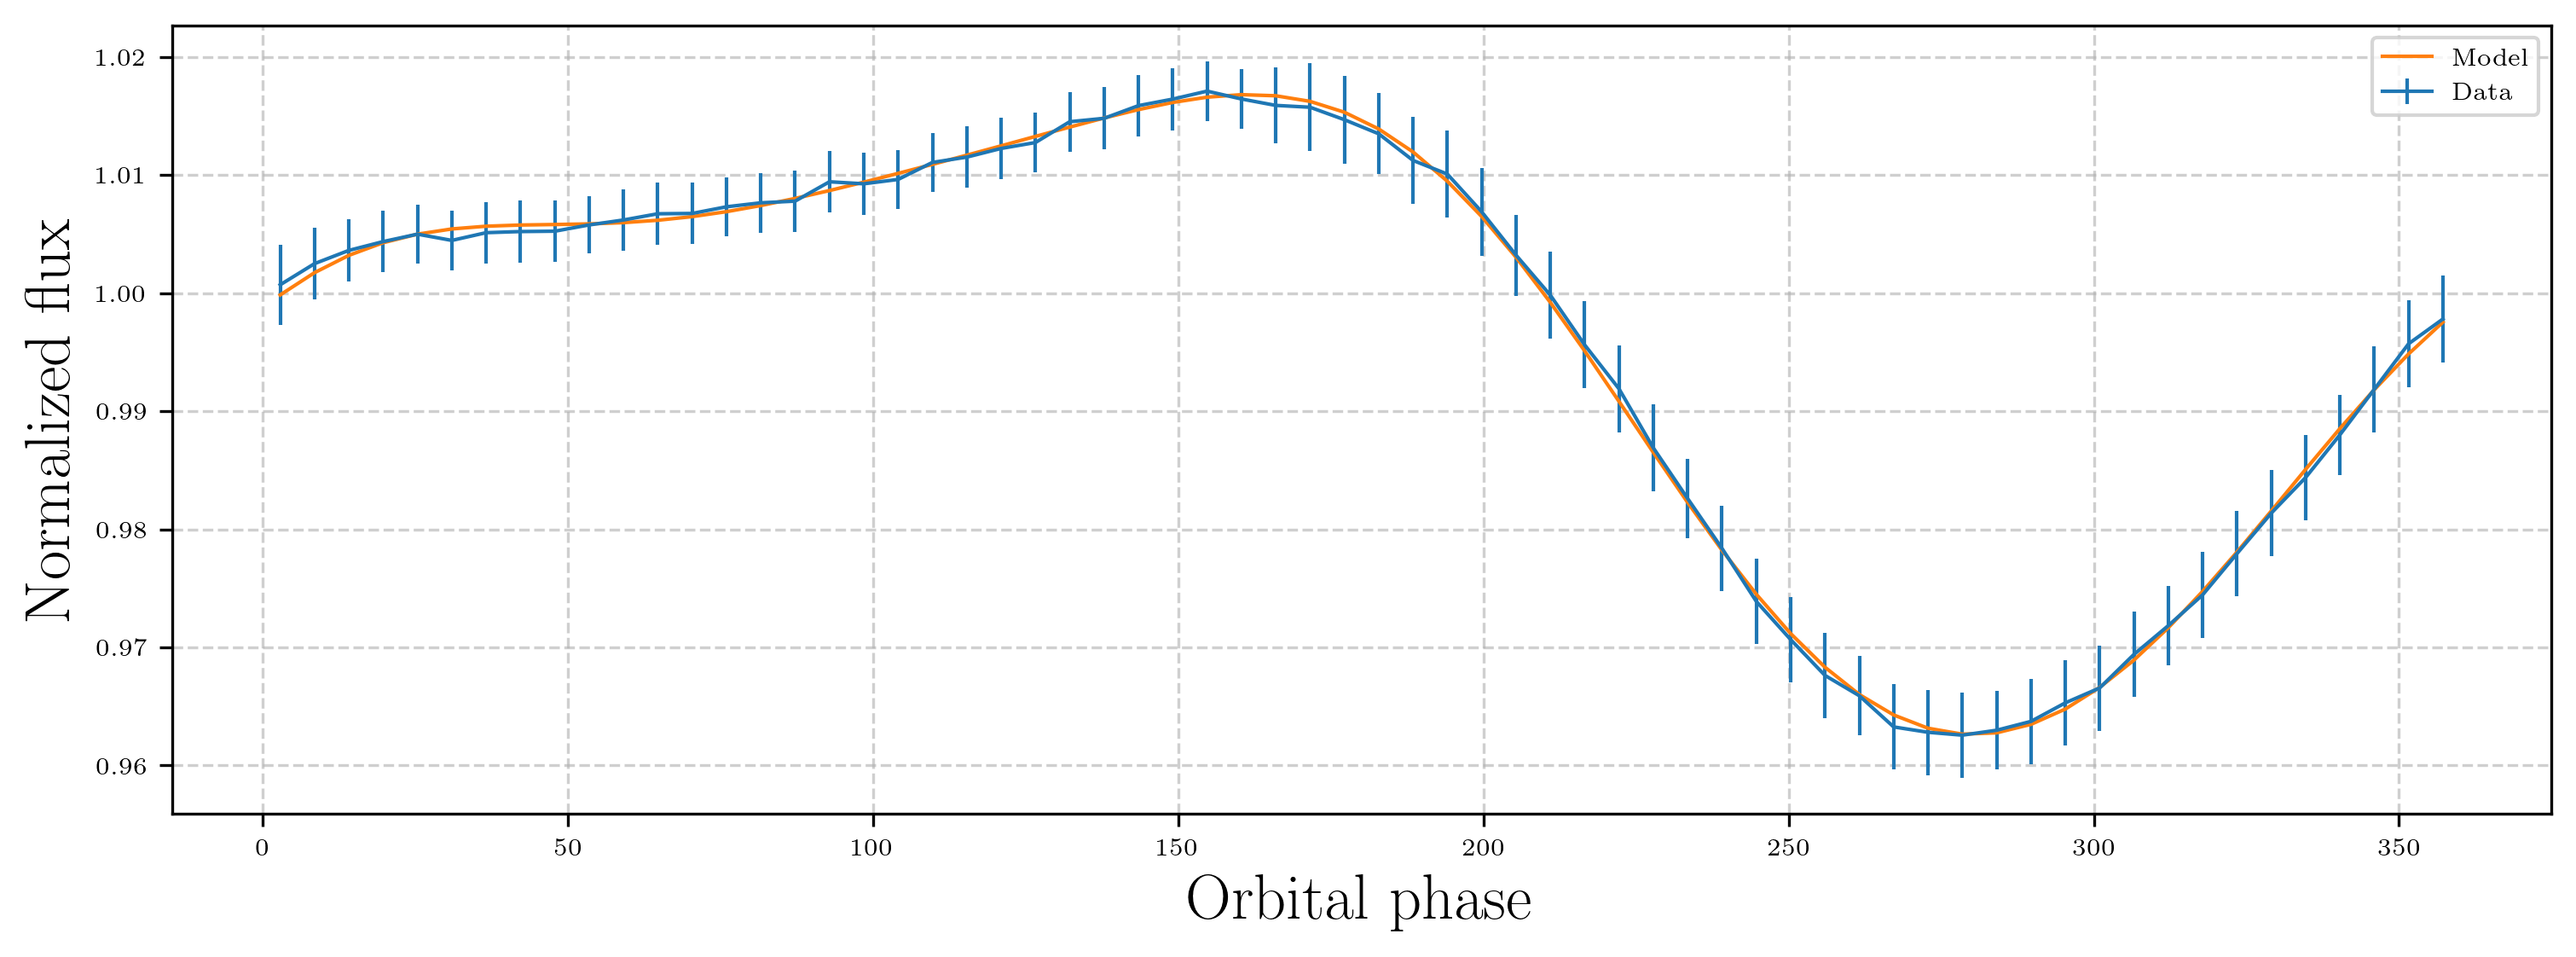

In [9]:
import starry
map = starry.Map(ydeg=4, udeg=2)
map[1] = 0.2
map[2] = 0
map.inc = 90
kwargs = dict(theta=theta_23)
mu = np.empty(map.Ny)
mu[0] = 1
mu[1:] = 0
L = np.empty(map.Ny)
L[0] = 1e0
L[1:] = 1e-3
map.set_prior(L=L)
i_to_plot = np.argmin(abs(wl_24-1.75))  # Index of wavelength to plot

map.set_data(flux_24[i_to_plot], C=flux_err_24[i_to_plot] ** 2)
map.solve(**kwargs)
map.show(projection="moll", colorbar=True)
fig, ax = plt.subplots(1, figsize=(12, 4))
ax.errorbar(theta_24, flux_24[i_to_plot], yerr=flux_err_24[i_to_plot], label="Data")
ax.plot(theta_24, map.flux(**kwargs), label="Model")
ax.set_xlabel("Orbital phase", fontsize=18)
ax.set_ylabel("Normalized flux", fontsize=18)
ax.legend()

### Find Optimal Map Complexity
We now solve for the maps. Since we don't know the complexity of the surface beforehand, we test spherical harmonic degrees ranging from `ydeg=2` to `ydeg=10`. The algorithm will automatically select the degree that best fits the data without overfitting (using the Bayesian Information Criterion).

In [ ]:
from spectralmap.mapping import make_maps
maps = make_maps(mode='rotational', map_res=30, ydegs=np.arange(2, 9), projection='rect', u=[0, 0])

In [43]:
# Solve for the best spherical harmonic degree (ydeg) for each wavelength
# This optimizes the model complexity (model evidence) to avoid overfitting
data = data_23
amplitudes = amplitudes_23
wl = wl_23
_, I_all_wl, I_cov_all_wl = maps.marginalized_maps(data)
F_all_wl = I_all_wl * amplitudes[:, None] *np.pi
F_cov_all_wl = I_cov_all_wl * (np.pi * amplitudes[:, None, None])**2
F_var_all_wl = np.diagonal(F_cov_all_wl, axis1=1, axis2=2)
F_all_wl_23 = F_all_wl
F_cov_all_wl_23 = F_cov_all_wl
F_var_all_wl_23 = F_var_all_wl

ydeg: 100%|██████████| 7/7 [01:36<00:00, 13.73s/it, wl 334/334]


lambda=None: Best-evidence wavelength counts by ydeg: ydeg=2: 12, ydeg=3: 0, ydeg=4: 197, ydeg=5: 76, ydeg=6: 34, ydeg=7: 15, ydeg=8: 0


In [44]:
# Solve for the best spherical harmonic degree (ydeg) for each wavelength
# This optimizes the model complexity (model evidence) to avoid overfitting
data = data_24
amplitudes = amplitudes_24
wl = wl_24
_, I_all_wl, I_cov_all_wl = maps.marginalized_maps(data)
F_all_wl = I_all_wl * amplitudes[:, None] *np.pi
F_cov_all_wl = I_cov_all_wl * (np.pi * amplitudes[:, None, None])**2
F_var_all_wl = np.diagonal(F_cov_all_wl, axis1=1, axis2=2)
F_all_wl_24 = F_all_wl
F_cov_all_wl_24 = F_cov_all_wl
F_var_all_wl_24 = F_var_all_wl

ydeg: 100%|██████████| 7/7 [01:46<00:00, 15.18s/it, wl 363/363]


lambda=None: Best-evidence wavelength counts by ydeg: ydeg=2: 359, ydeg=3: 0, ydeg=4: 3, ydeg=5: 1, ydeg=6: 0, ydeg=7: 0, ydeg=8: 0


In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Build the latitude array corresponding to the F_all_wl pixel axis.
valid_mask = maps.moll_mask_flat & maps.observed_mask
lat_vals = maps.lat_flat[valid_mask]

# Fallback in case this notebook state uses observed_mask without moll filtering.
if F_all_wl.shape[1] != lat_vals.size:
    lat_vals = maps.lat_flat[maps.observed_mask]

# Convert to degrees if the stored latitudes are in radians.
lat_deg = np.rad2deg(lat_vals) if np.nanmax(np.abs(lat_vals)) <= (np.pi + 0.1) else lat_vals

# Define latitude bands: polar (both hemispheres) and equatorial.
polar_mask = np.abs(lat_deg) > 70.0
equator_mask = np.abs(lat_deg) < 20.0

if not np.any(polar_mask) or not np.any(equator_mask):
    raise ValueError("No pixels found in one of the requested latitude bins. Check map latitude grid.")

# Area-like weights for latitude averaging on a sphere.
weights = np.cos(np.deg2rad(lat_deg))
weights = np.clip(weights, 0.0, None)

def weighted_mean_and_err(flux_2d, cov_3d, pix_mask, w):
    idx = np.where(pix_mask)[0]
    w_sel = w[idx]
    wsum = np.sum(w_sel)
    w_norm = w_sel / wsum

    f_sel = flux_2d[:, idx]
    mean = np.einsum("wp,p->w", f_sel, w_norm)

    # Propagate full covariance of the weighted mean: var = w^T C w
    cov_sel = cov_3d[:, idx, :][:, :, idx]
    var = np.einsum("p,wpq,q->w", w_norm, cov_sel, w_norm)
    err = np.sqrt(np.clip(var, 0.0, None))
    return mean, err

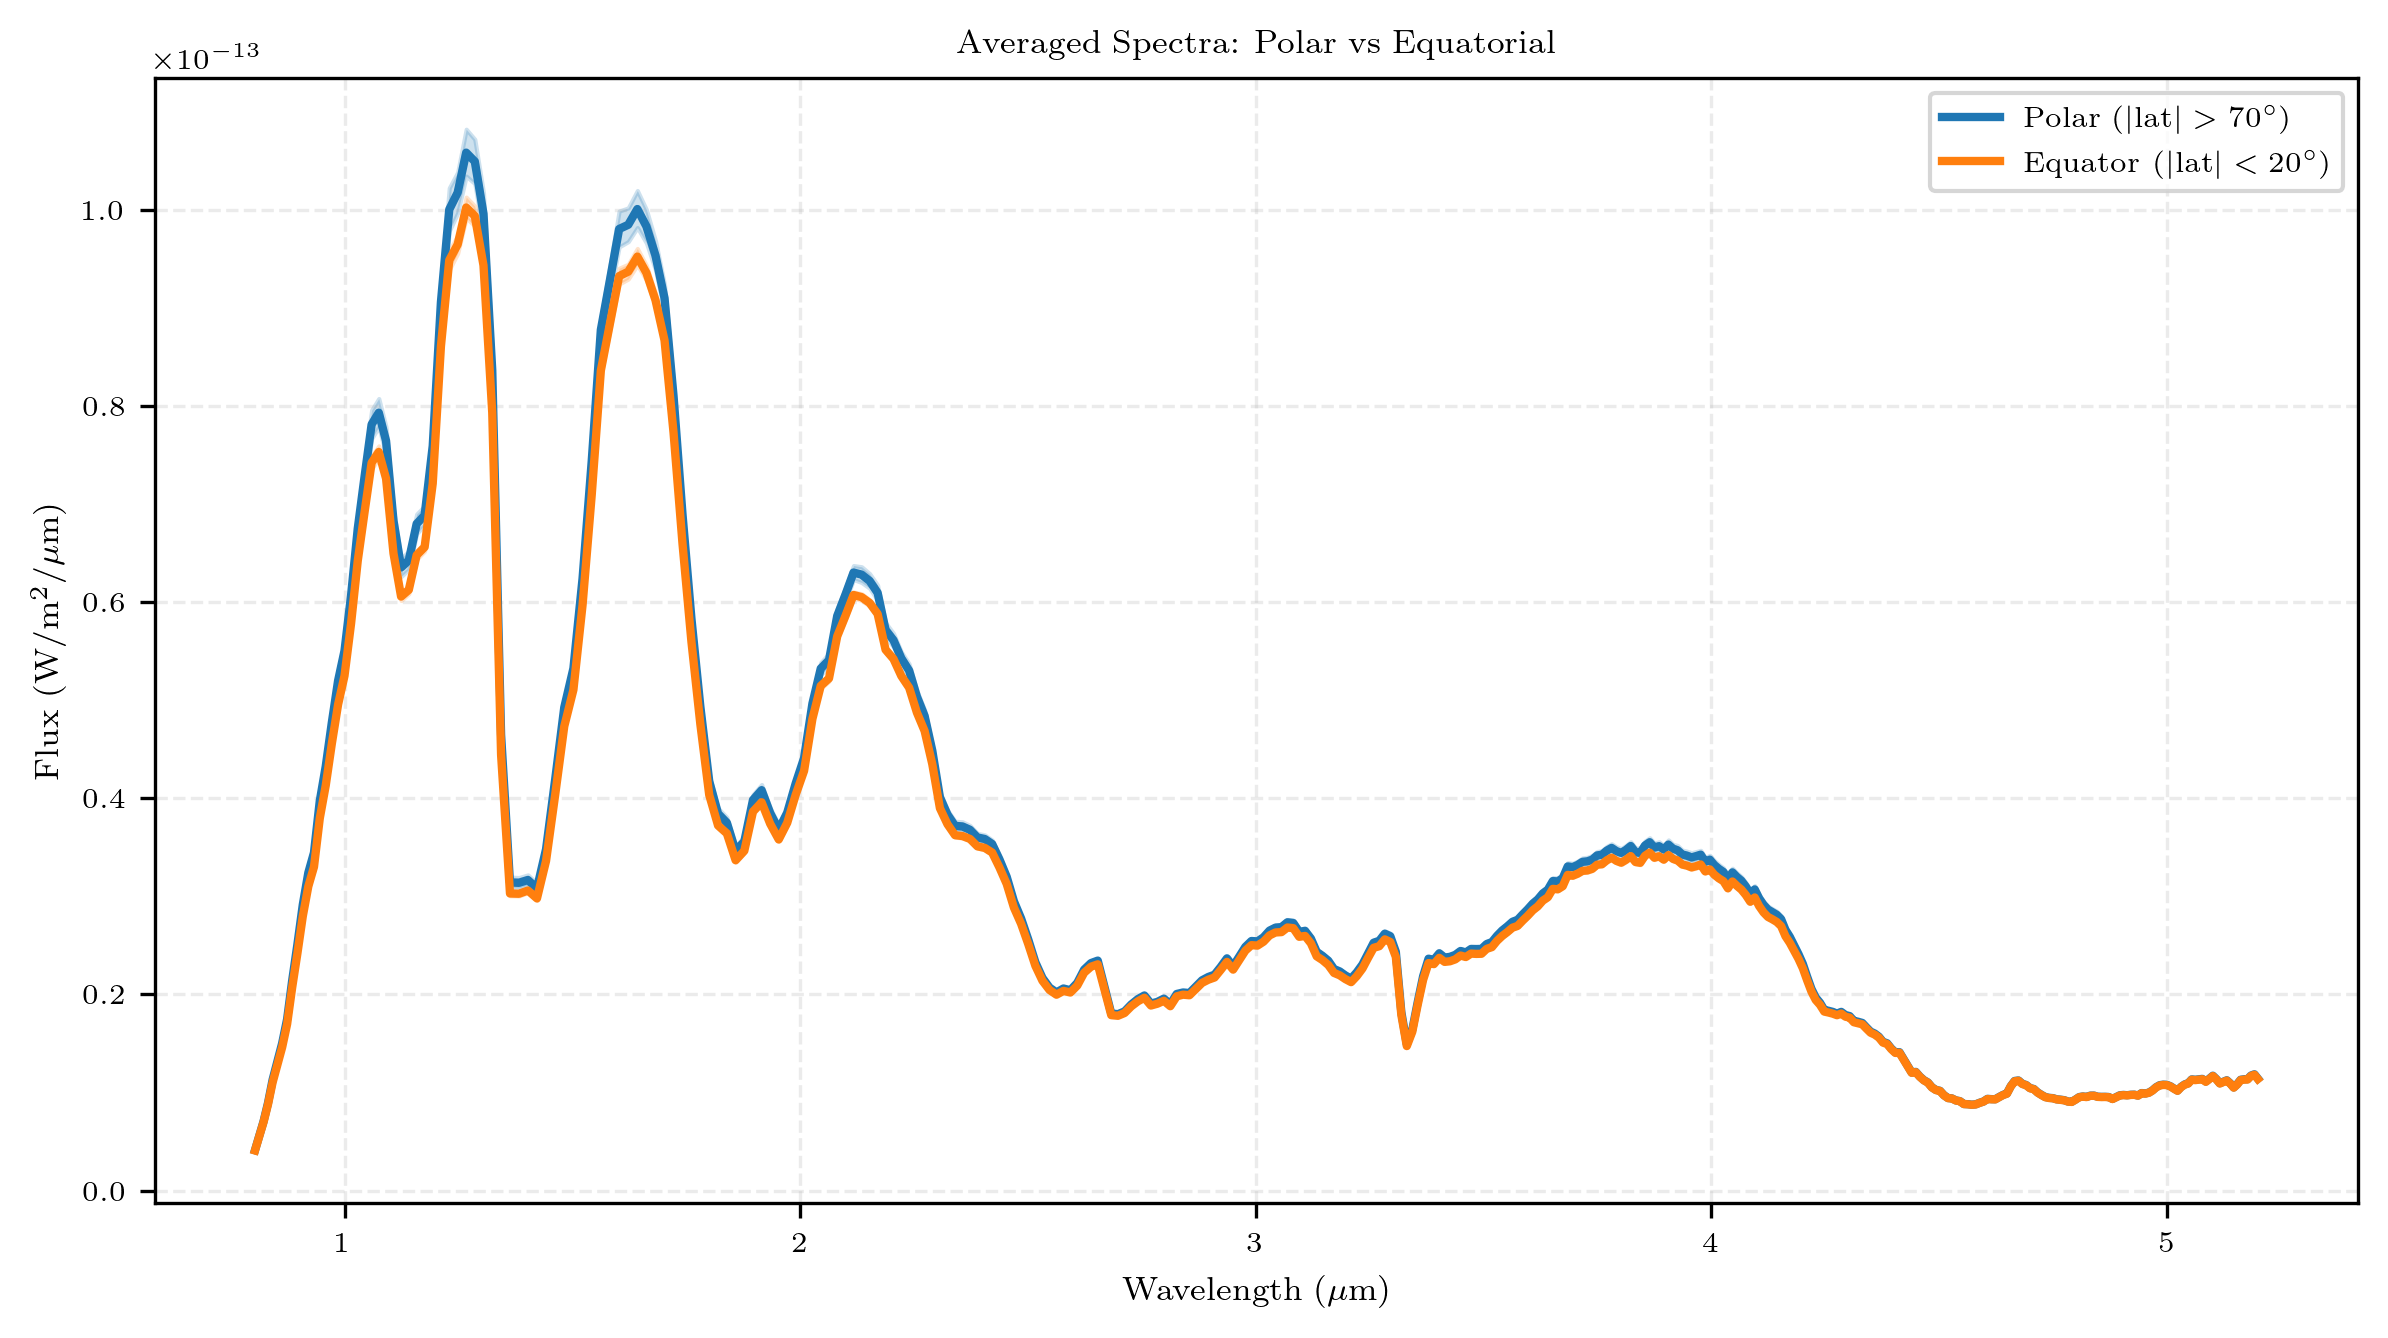

In [46]:
F_all_wl = F_all_wl_24
F_cov_all_wl = F_cov_all_wl_24
wl = wl_24
polar_flux, polar_err = weighted_mean_and_err(F_all_wl, F_cov_all_wl, polar_mask, weights)
equator_flux, equator_err = weighted_mean_and_err(F_all_wl, F_cov_all_wl, equator_mask, weights)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(
    wl,
    polar_flux,
    lw=2.0,
    color='tab:blue',
    label=r'Polar ($|\mathrm{lat}| > 70^\circ$)'
)
ax.fill_between(
    wl,
    polar_flux - polar_err,
    polar_flux + polar_err,
    color='tab:blue',
    alpha=0.22,
)

ax.plot(
    wl,
    equator_flux,
    lw=2.0,
    color='tab:orange',
    label=r'Equator ($|\mathrm{lat}| < 20^\circ$)'
)
ax.fill_between(
    wl,
    equator_flux - equator_err,
    equator_flux + equator_err,
    color='tab:orange',
    alpha=0.22,
)

ax.set_xlabel(r"Wavelength ($\mu$m)")
ax.set_ylabel(r"Flux (W/m$^2$/$\mu$m)")
ax.set_title("Averaged Spectra: Polar vs Equatorial")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

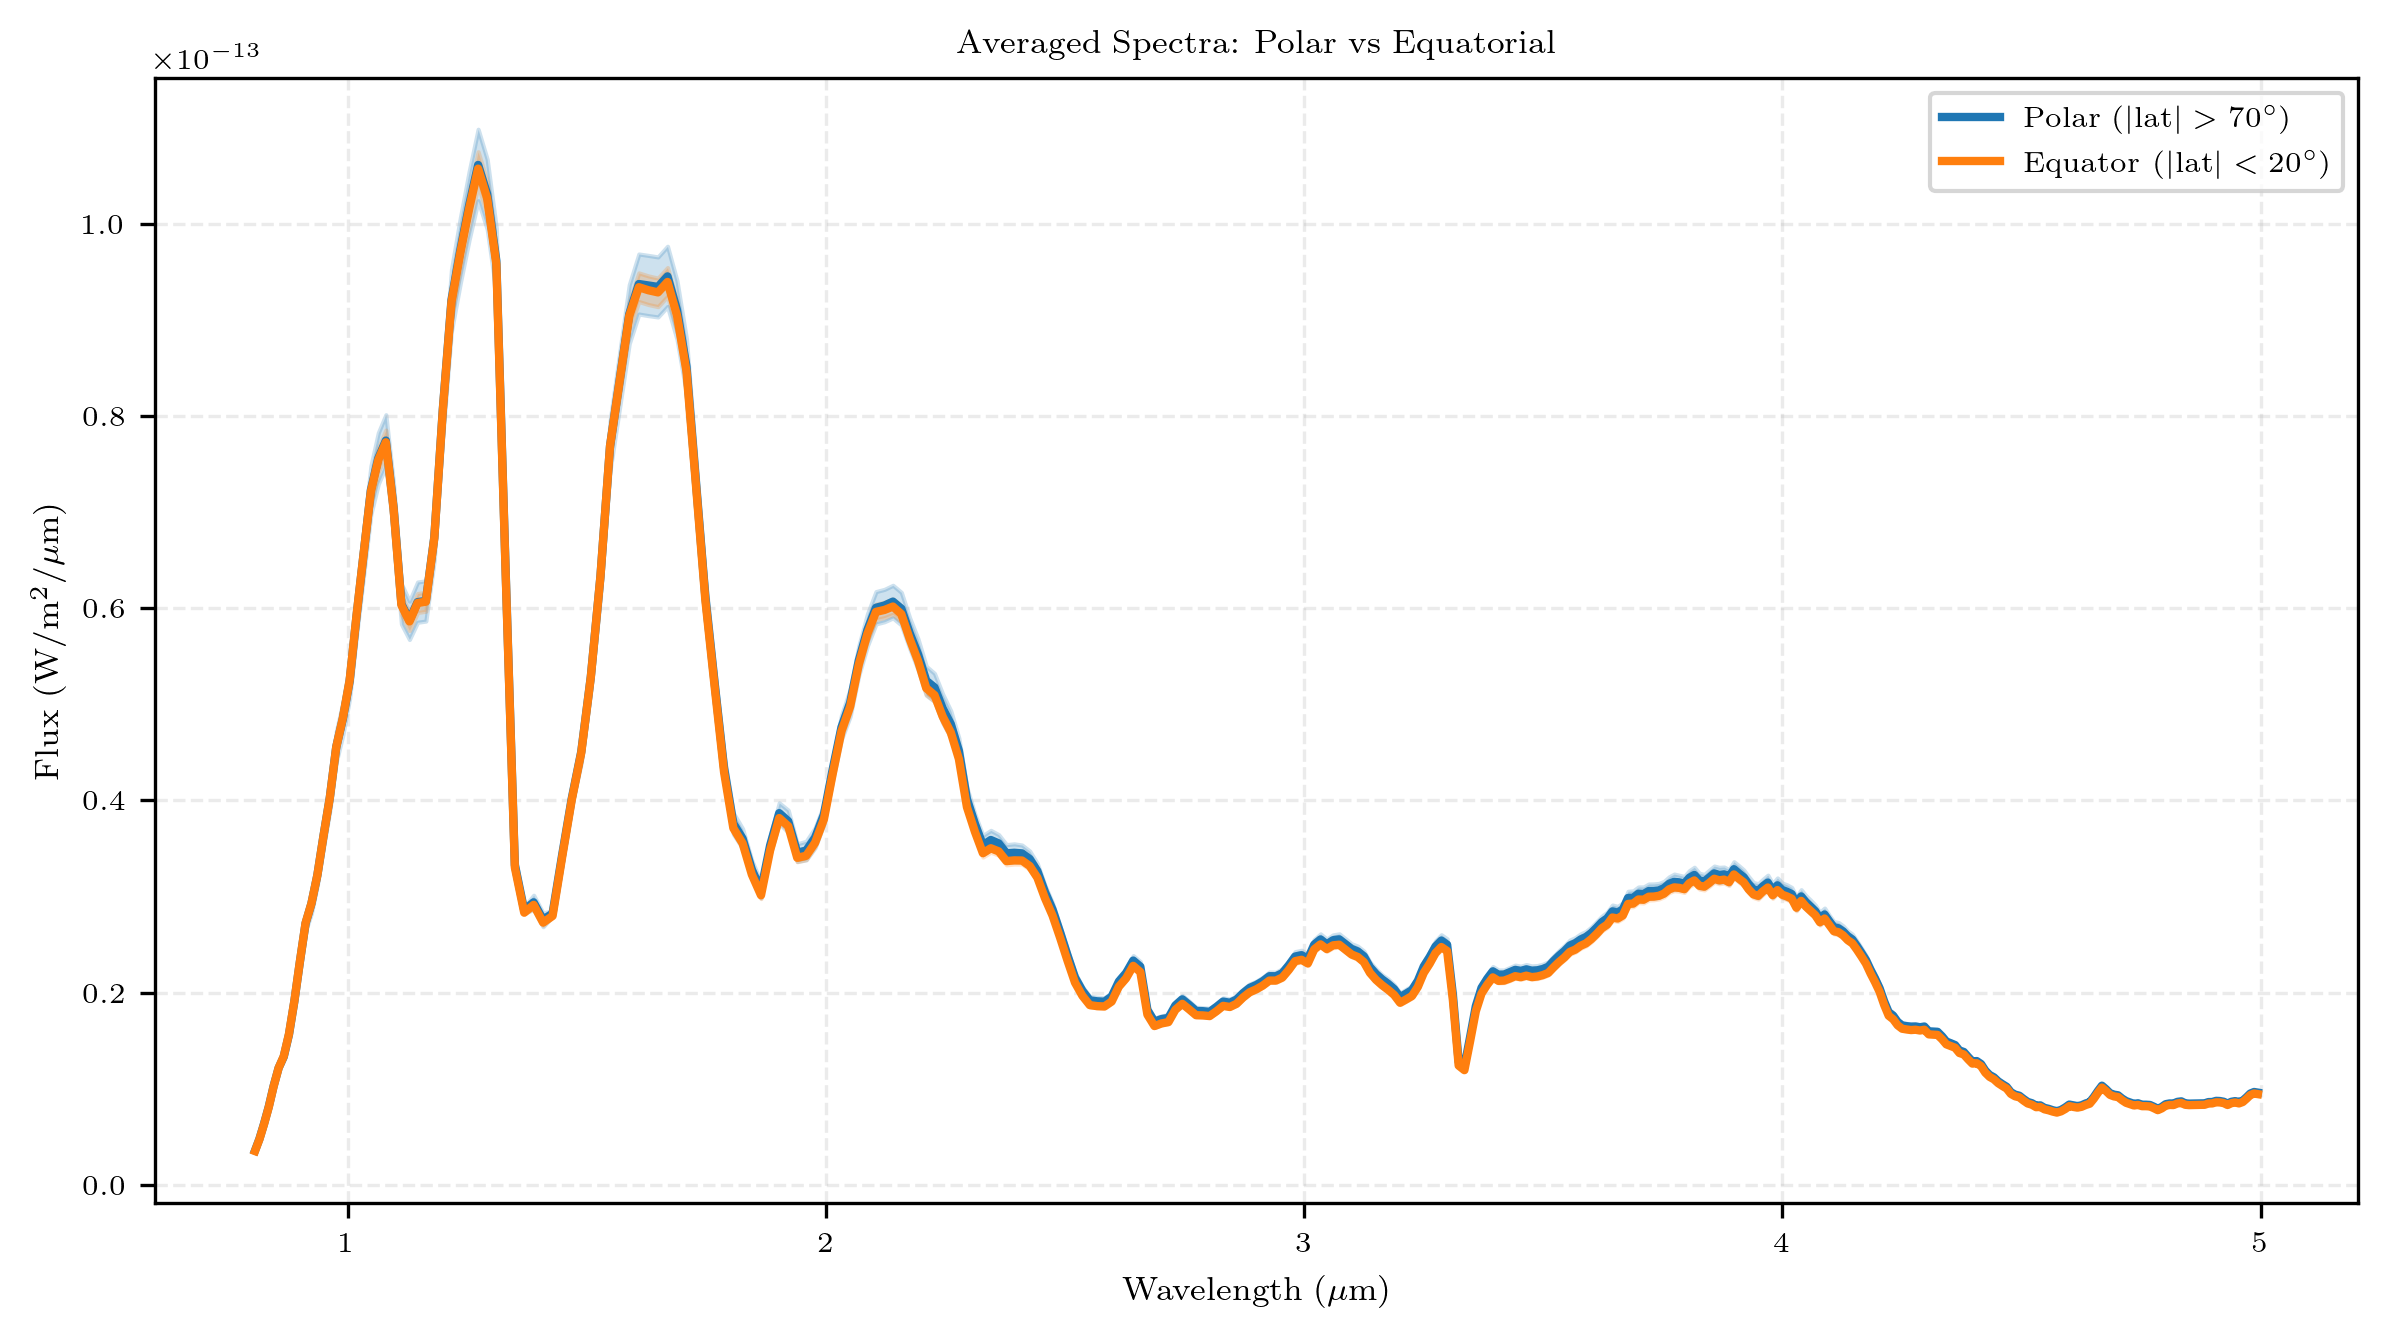

In [47]:
F_all_wl = F_all_wl_23
F_cov_all_wl = F_cov_all_wl_23
wl = wl_23

polar_flux, polar_err = weighted_mean_and_err(F_all_wl, F_cov_all_wl, polar_mask, weights)
equator_flux, equator_err = weighted_mean_and_err(F_all_wl, F_cov_all_wl, equator_mask, weights)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(
    wl,
    polar_flux,
    lw=2.0,
    color='tab:blue',
    label=r'Polar ($|\mathrm{lat}| > 70^\circ$)'
)
ax.fill_between(
    wl,
    polar_flux - polar_err,
    polar_flux + polar_err,
    color='tab:blue',
    alpha=0.22,
)

ax.plot(
    wl,
    equator_flux,
    lw=2.0,
    color='tab:orange',
    label=r'Equator ($|\mathrm{lat}| < 20^\circ$)'
)
ax.fill_between(
    wl,
    equator_flux - equator_err,
    equator_flux + equator_err,
    color='tab:orange',
    alpha=0.22,
)

ax.set_xlabel(r"Wavelength ($\mu$m)")
ax.set_ylabel(r"Flux (W/m$^2$/$\mu$m)")
ax.set_title("Averaged Spectra: Polar vs Equatorial")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

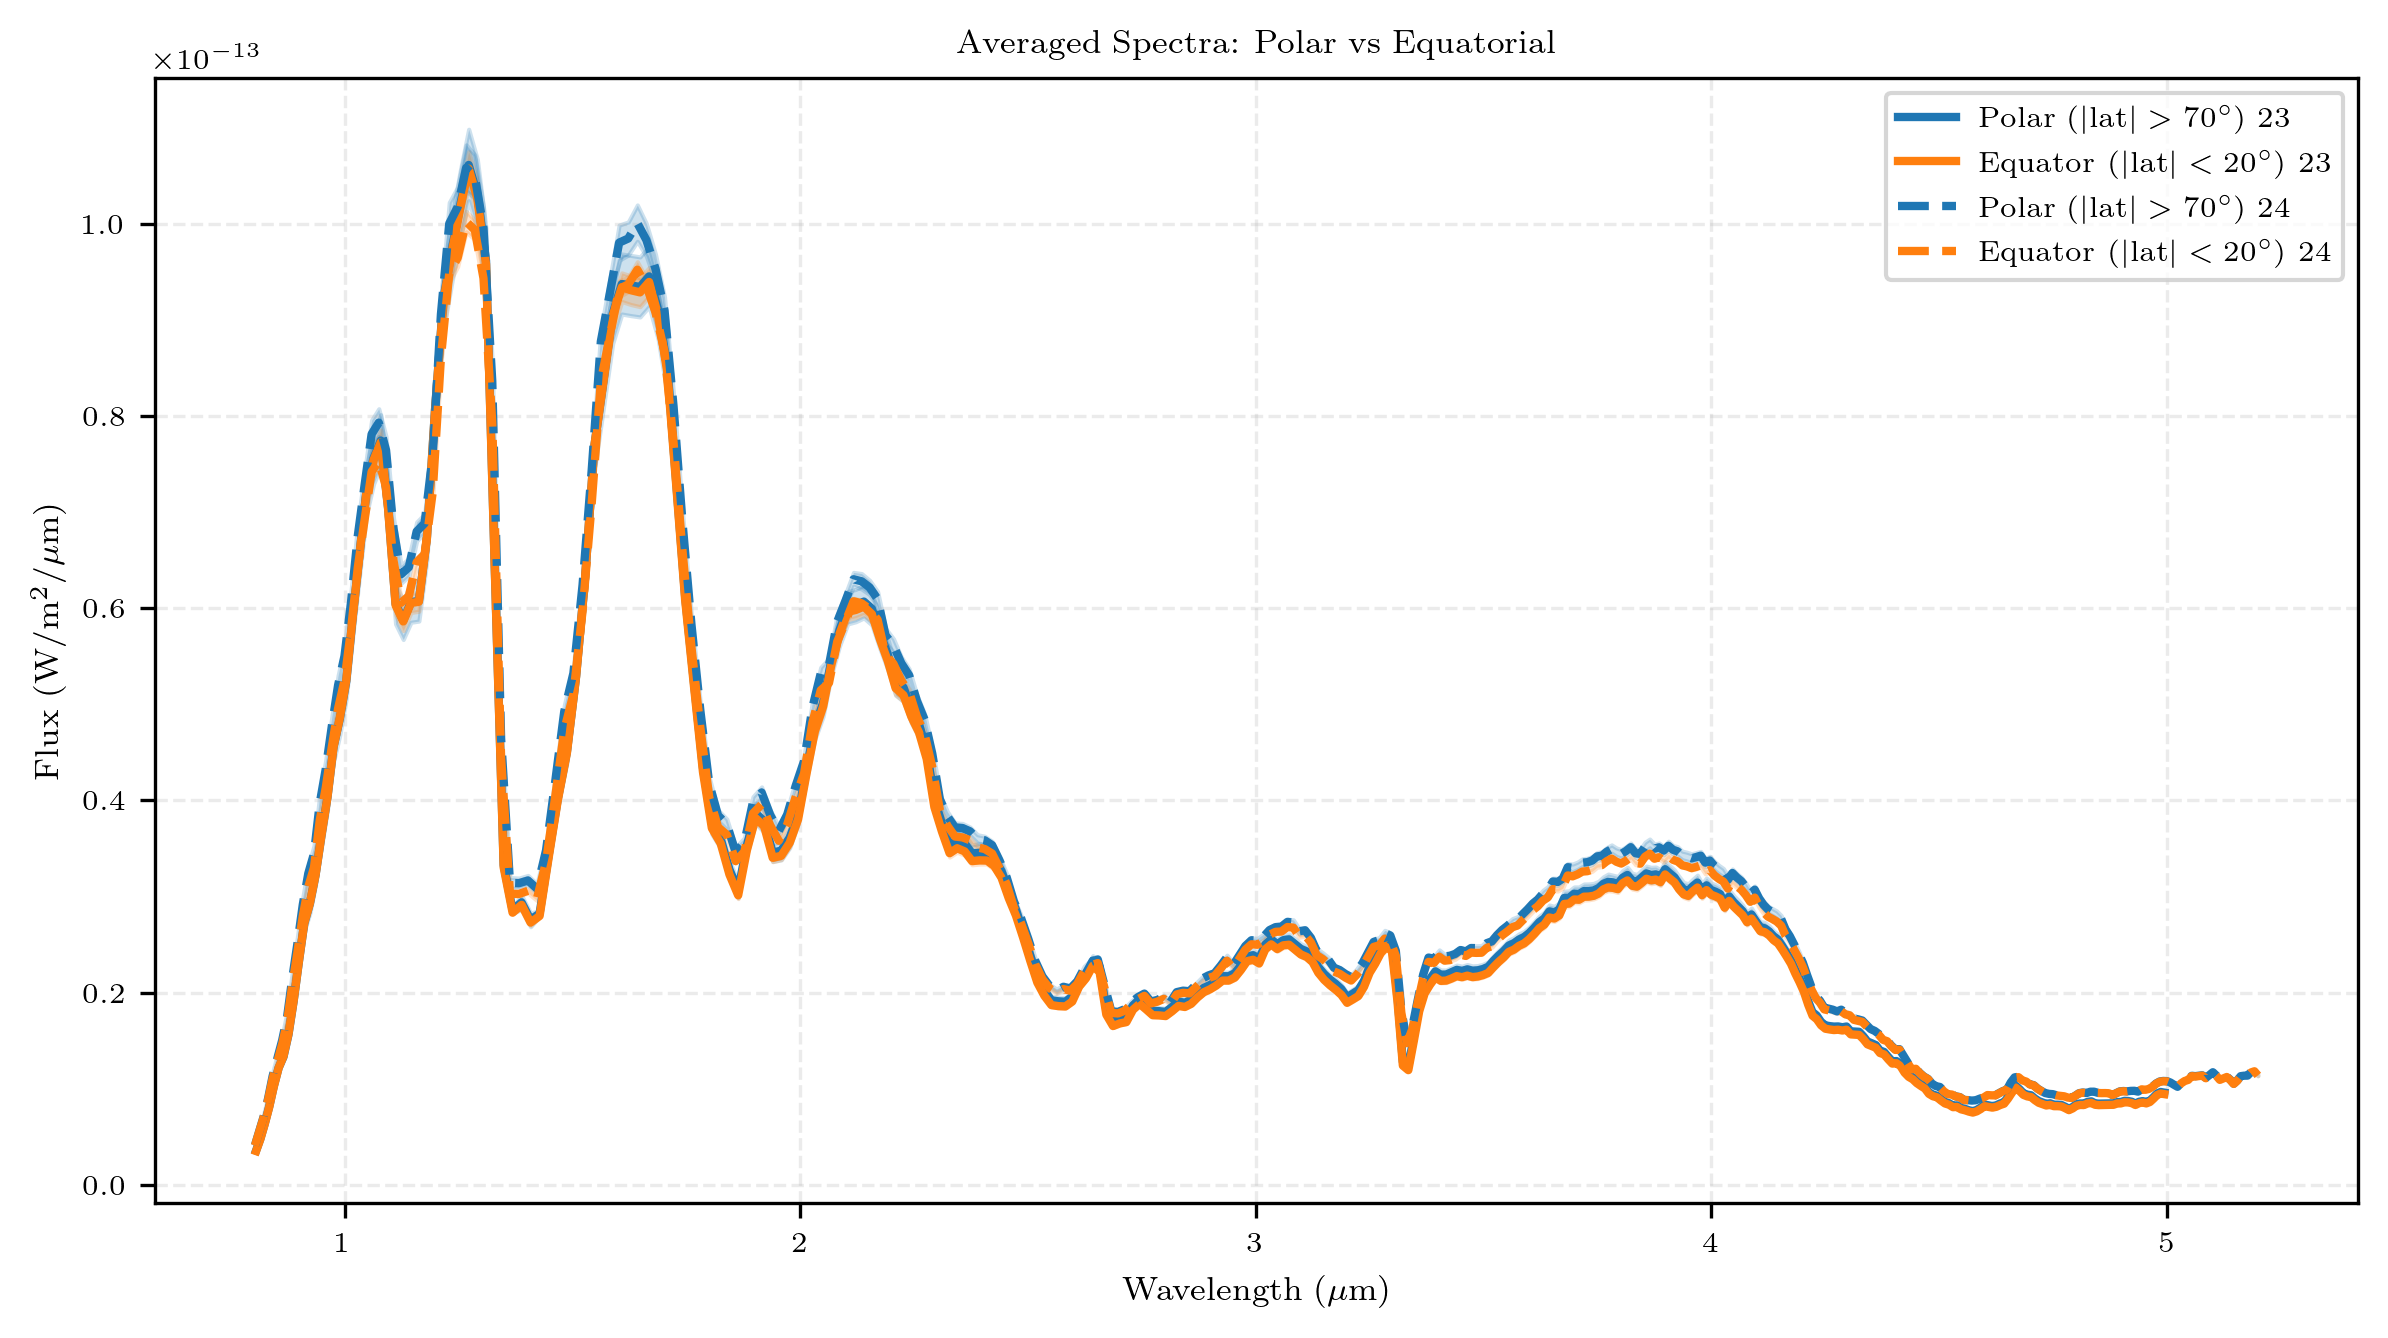

In [48]:
F_all_wl = F_all_wl_23
F_cov_all_wl = F_cov_all_wl_23
wl = wl_23

polar_flux, polar_err = weighted_mean_and_err(F_all_wl, F_cov_all_wl, polar_mask, weights)
equator_flux, equator_err = weighted_mean_and_err(F_all_wl, F_cov_all_wl, equator_mask, weights)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(
    wl,
    polar_flux,
    lw=2.0,
    color='tab:blue',
    label=r'Polar ($|\mathrm{lat}| > 70^\circ$) 23'
)
ax.fill_between(
    wl,
    polar_flux - polar_err,
    polar_flux + polar_err,
    color='tab:blue',
    alpha=0.22,
)

ax.plot(
    wl,
    equator_flux,
    lw=2.0,
    color='tab:orange',
    label=r'Equator ($|\mathrm{lat}| < 20^\circ$) 23'
)
ax.fill_between(
    wl,
    equator_flux - equator_err,
    equator_flux + equator_err,
    color='tab:orange',
    alpha=0.22,
)

F_all_wl = F_all_wl_24
F_cov_all_wl = F_cov_all_wl_24
wl = wl_24

polar_flux, polar_err = weighted_mean_and_err(F_all_wl, F_cov_all_wl, polar_mask, weights)
equator_flux, equator_err = weighted_mean_and_err(F_all_wl, F_cov_all_wl, equator_mask, weights)

ax.plot(
    wl,
    polar_flux,
    lw=2.0,
    color='tab:blue',
    label=r'Polar ($|\mathrm{lat}| > 70^\circ$) 24',
    linestyle='--'
)
ax.fill_between(
    wl,
    polar_flux - polar_err,
    polar_flux + polar_err,
    color='tab:blue',
    alpha=0.22,
)

ax.plot(
    wl,
    equator_flux,
    lw=2.0,
    color='tab:orange',
    label=r'Equator ($|\mathrm{lat}| < 20^\circ$) 24',
    linestyle='--'
)

ax.fill_between(
    wl,
    equator_flux - equator_err,
    equator_flux + equator_err,
    color='tab:orange',
    alpha=0.22,
)

ax.set_xlabel(r"Wavelength ($\mu$m)")
ax.set_ylabel(r"Flux (W/m$^2$/$\mu$m)")
ax.set_title("Averaged Spectra: Polar vs Equatorial")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

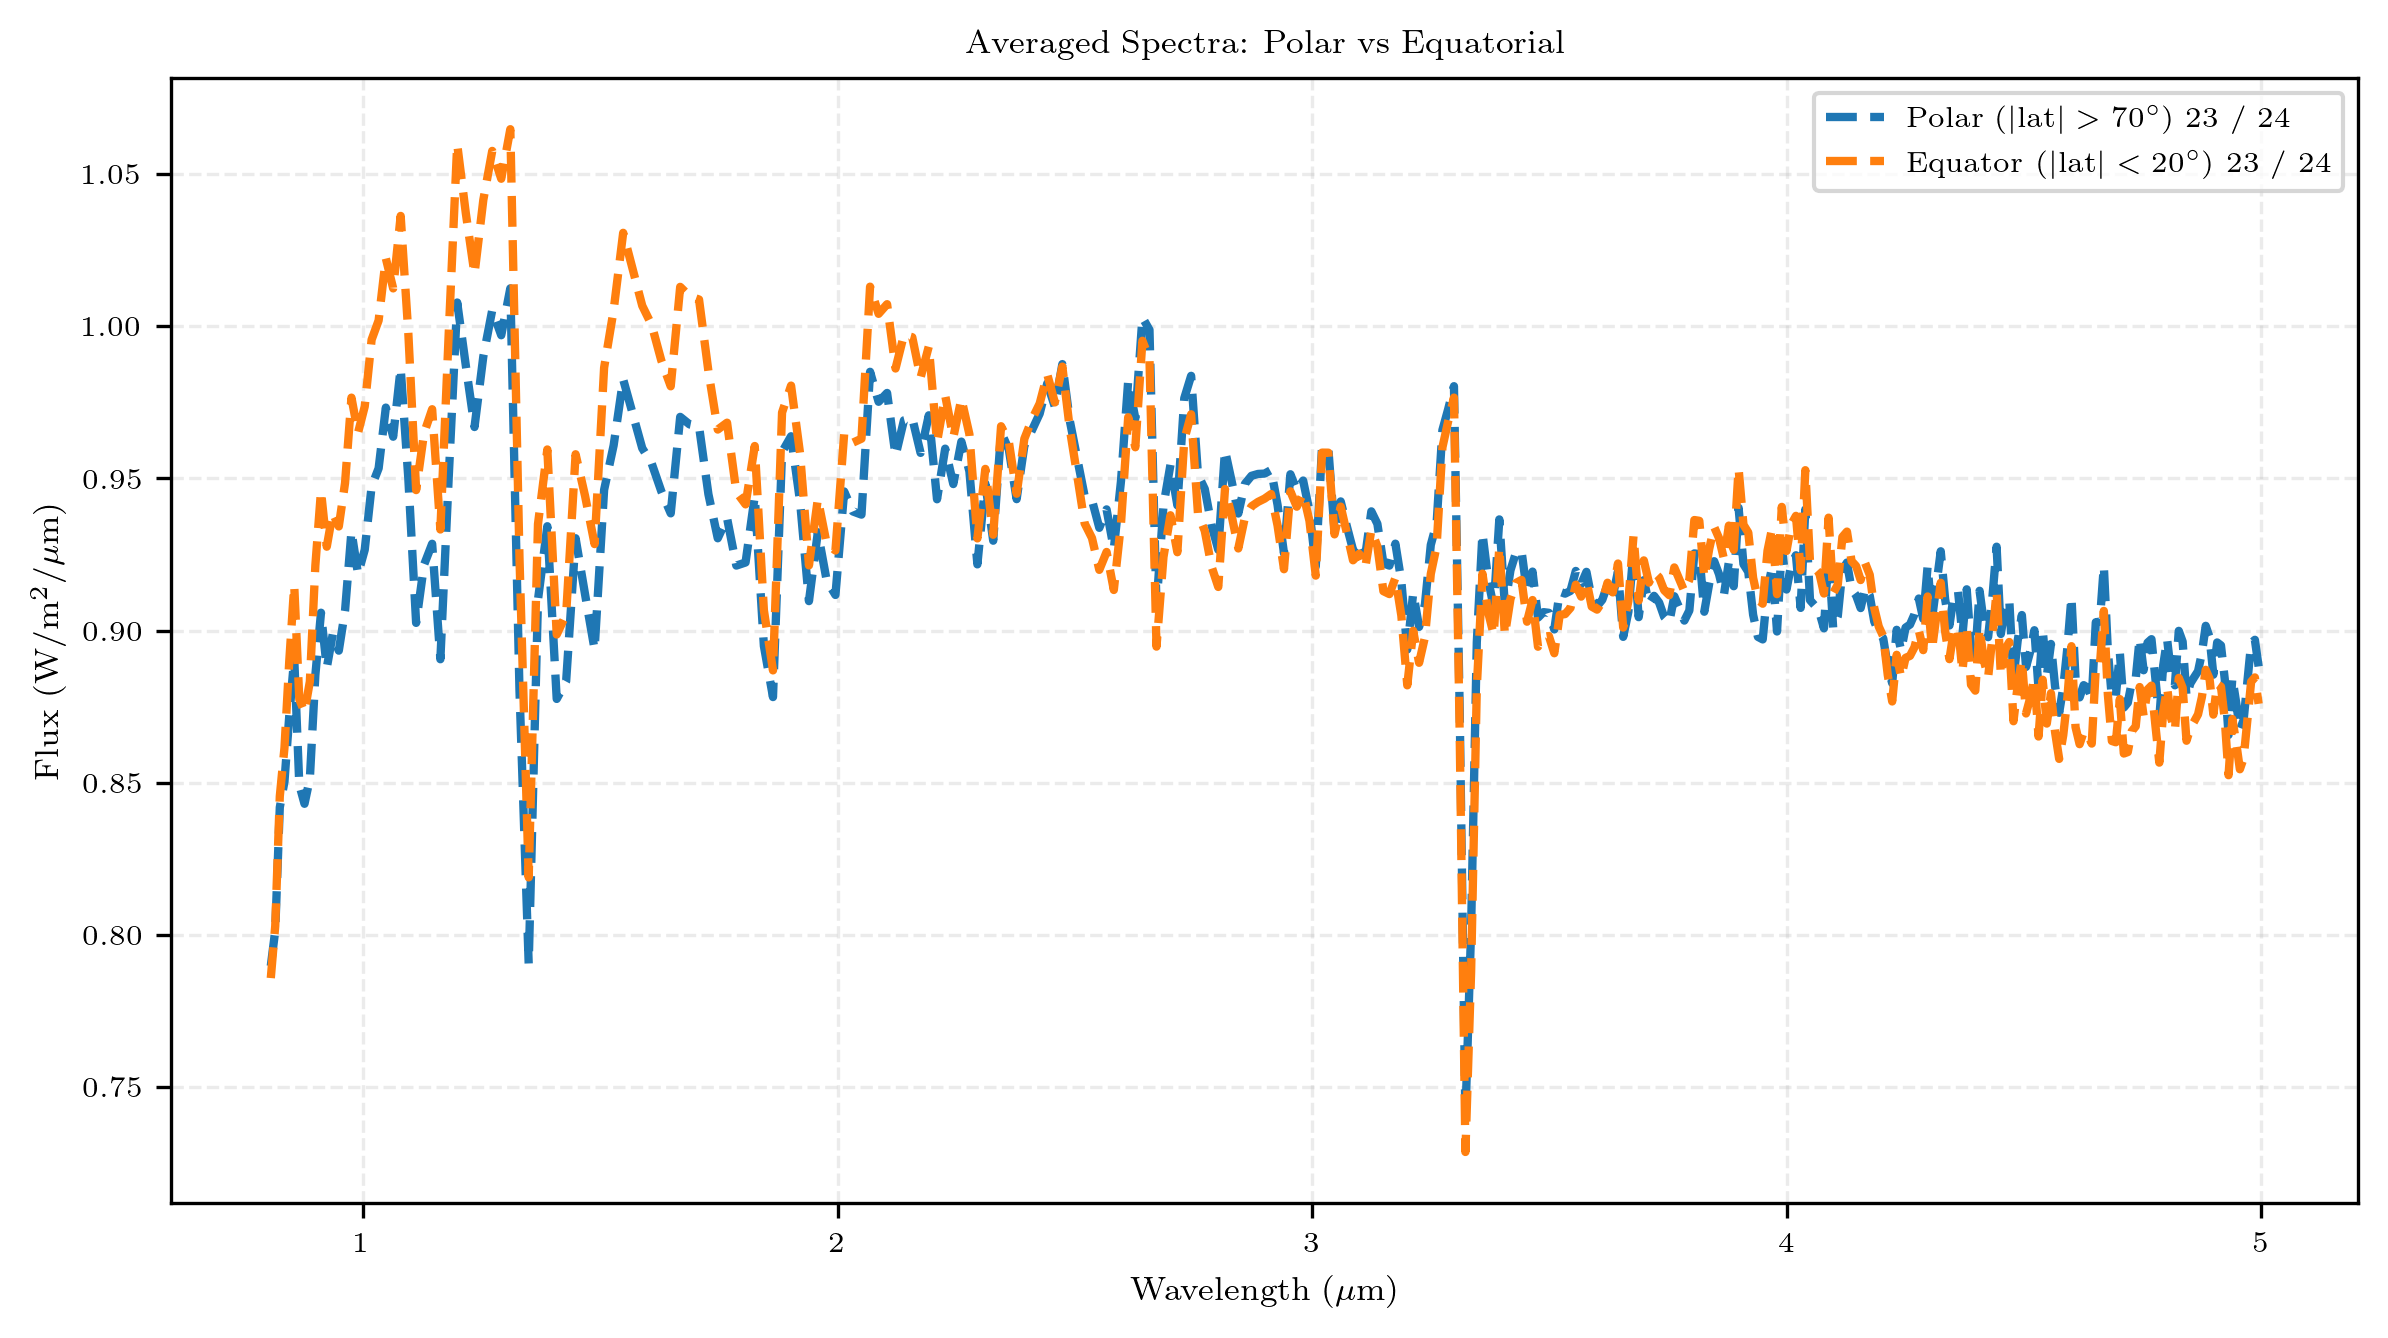

In [49]:
F_all_wl = F_all_wl_23
F_cov_all_wl = F_cov_all_wl_23
wl = wl_23

polar_flux, polar_err = weighted_mean_and_err(F_all_wl, F_cov_all_wl, polar_mask, weights)
equator_flux, equator_err = weighted_mean_and_err(F_all_wl, F_cov_all_wl, equator_mask, weights)

fig, ax = plt.subplots(figsize=(8, 4.5))

F_all_wl = F_all_wl_24
F_cov_all_wl = F_cov_all_wl_24
wl = wl_24

polar_flux_24, polar_err_24 = weighted_mean_and_err(F_all_wl, F_cov_all_wl, polar_mask, weights)
equator_flux_24, equator_err_24 = weighted_mean_and_err(F_all_wl, F_cov_all_wl, equator_mask, weights)

polar_flux_24 = np.interp(wl_23, wl_24, polar_flux_24)
equator_flux_24 = np.interp(wl_23, wl_24, equator_flux_24)
ax.plot(
    wl_23,
    polar_flux/polar_flux_24,
    lw=2.0,
    color='tab:blue',
    label=r'Polar ($|\mathrm{lat}| > 70^\circ$) 23 / 24',
    linestyle='--'
)

ax.plot(
    wl_23,
    equator_flux/equator_flux_24,
    lw=2.0,
    color='tab:orange',
    label=r'Equator ($|\mathrm{lat}| < 20^\circ$) 23 / 24',
    linestyle='--'
)


ax.set_xlabel(r"Wavelength ($\mu$m)")
ax.set_ylabel(r"Flux (W/m$^2$/$\mu$m)")
ax.set_title("Averaged Spectra: Polar vs Equatorial")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Clustering and Regional Identification
To make sense of the map, we group pixels that show similar spectral behavior using a clustering algorithm. This helps us identify distinct "regions" or features on the object's surface.

-1 500
0 200
1 200
[0.95994888 0.03294197]


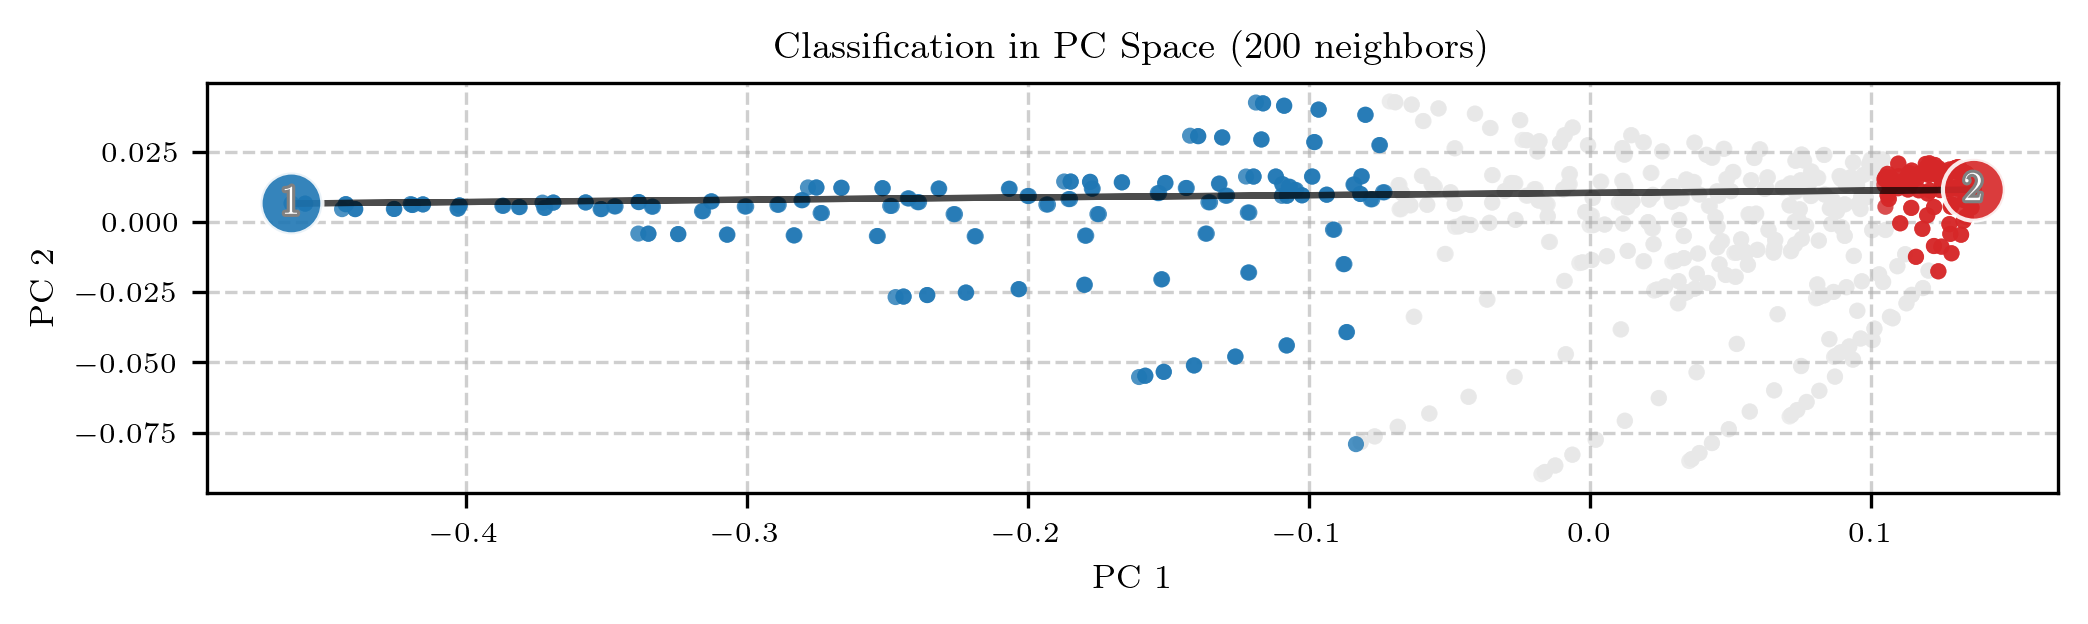

In [50]:
from spectralmap.cluster import find_clusters
F_regionals_24, F_regional_errs_24, labels_24 = find_clusters(F_all_wl_24, F_cov_all_wl_24, n_neighbors=200, n_corners=2)
N = len(F_regionals_24)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit_transform(np.log10(F_all_wl_24).T)
print(pca.explained_variance_ratio_)

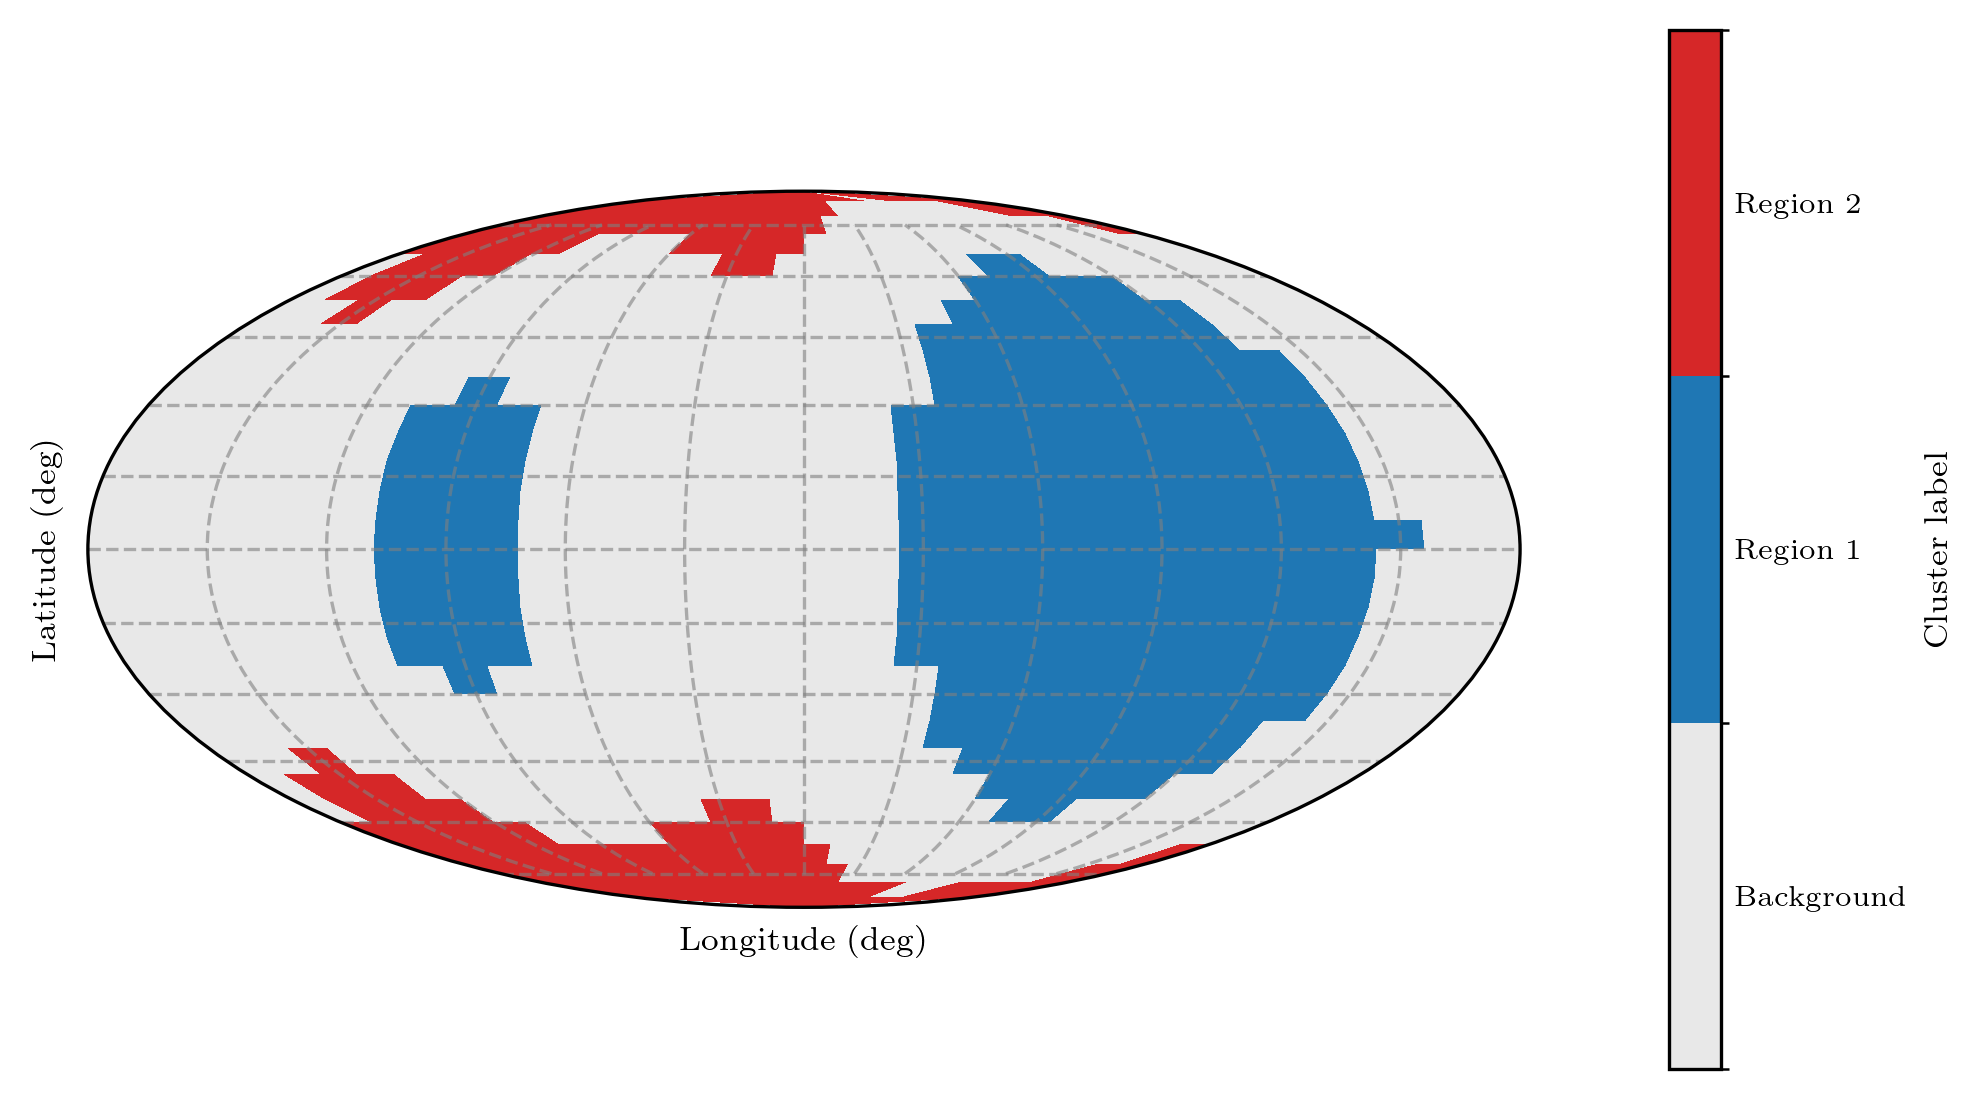

In [51]:
from spectralmap.plotting import plot_mollweide_labels
from matplotlib import colors as mcolors

color_list = COLOR_LIST[:N]
cluster_names = ["Background"] + [f"Region {i+1}" for i in range(N - 1)]
cmap = mcolors.ListedColormap(color_list)

fig, ax, pcm, cb = plot_mollweide_labels(
    labels_masked=labels_24,      # should be ints 0..N-1 on masked pixels
    moll_mask=maps.moll_mask,
    map_res=maps.map_res,
    cmap=cmap,
    names=cluster_names
)

# output_path = PAPER_FIGURES_DIR / "S0136_recovered_regions.pdf"

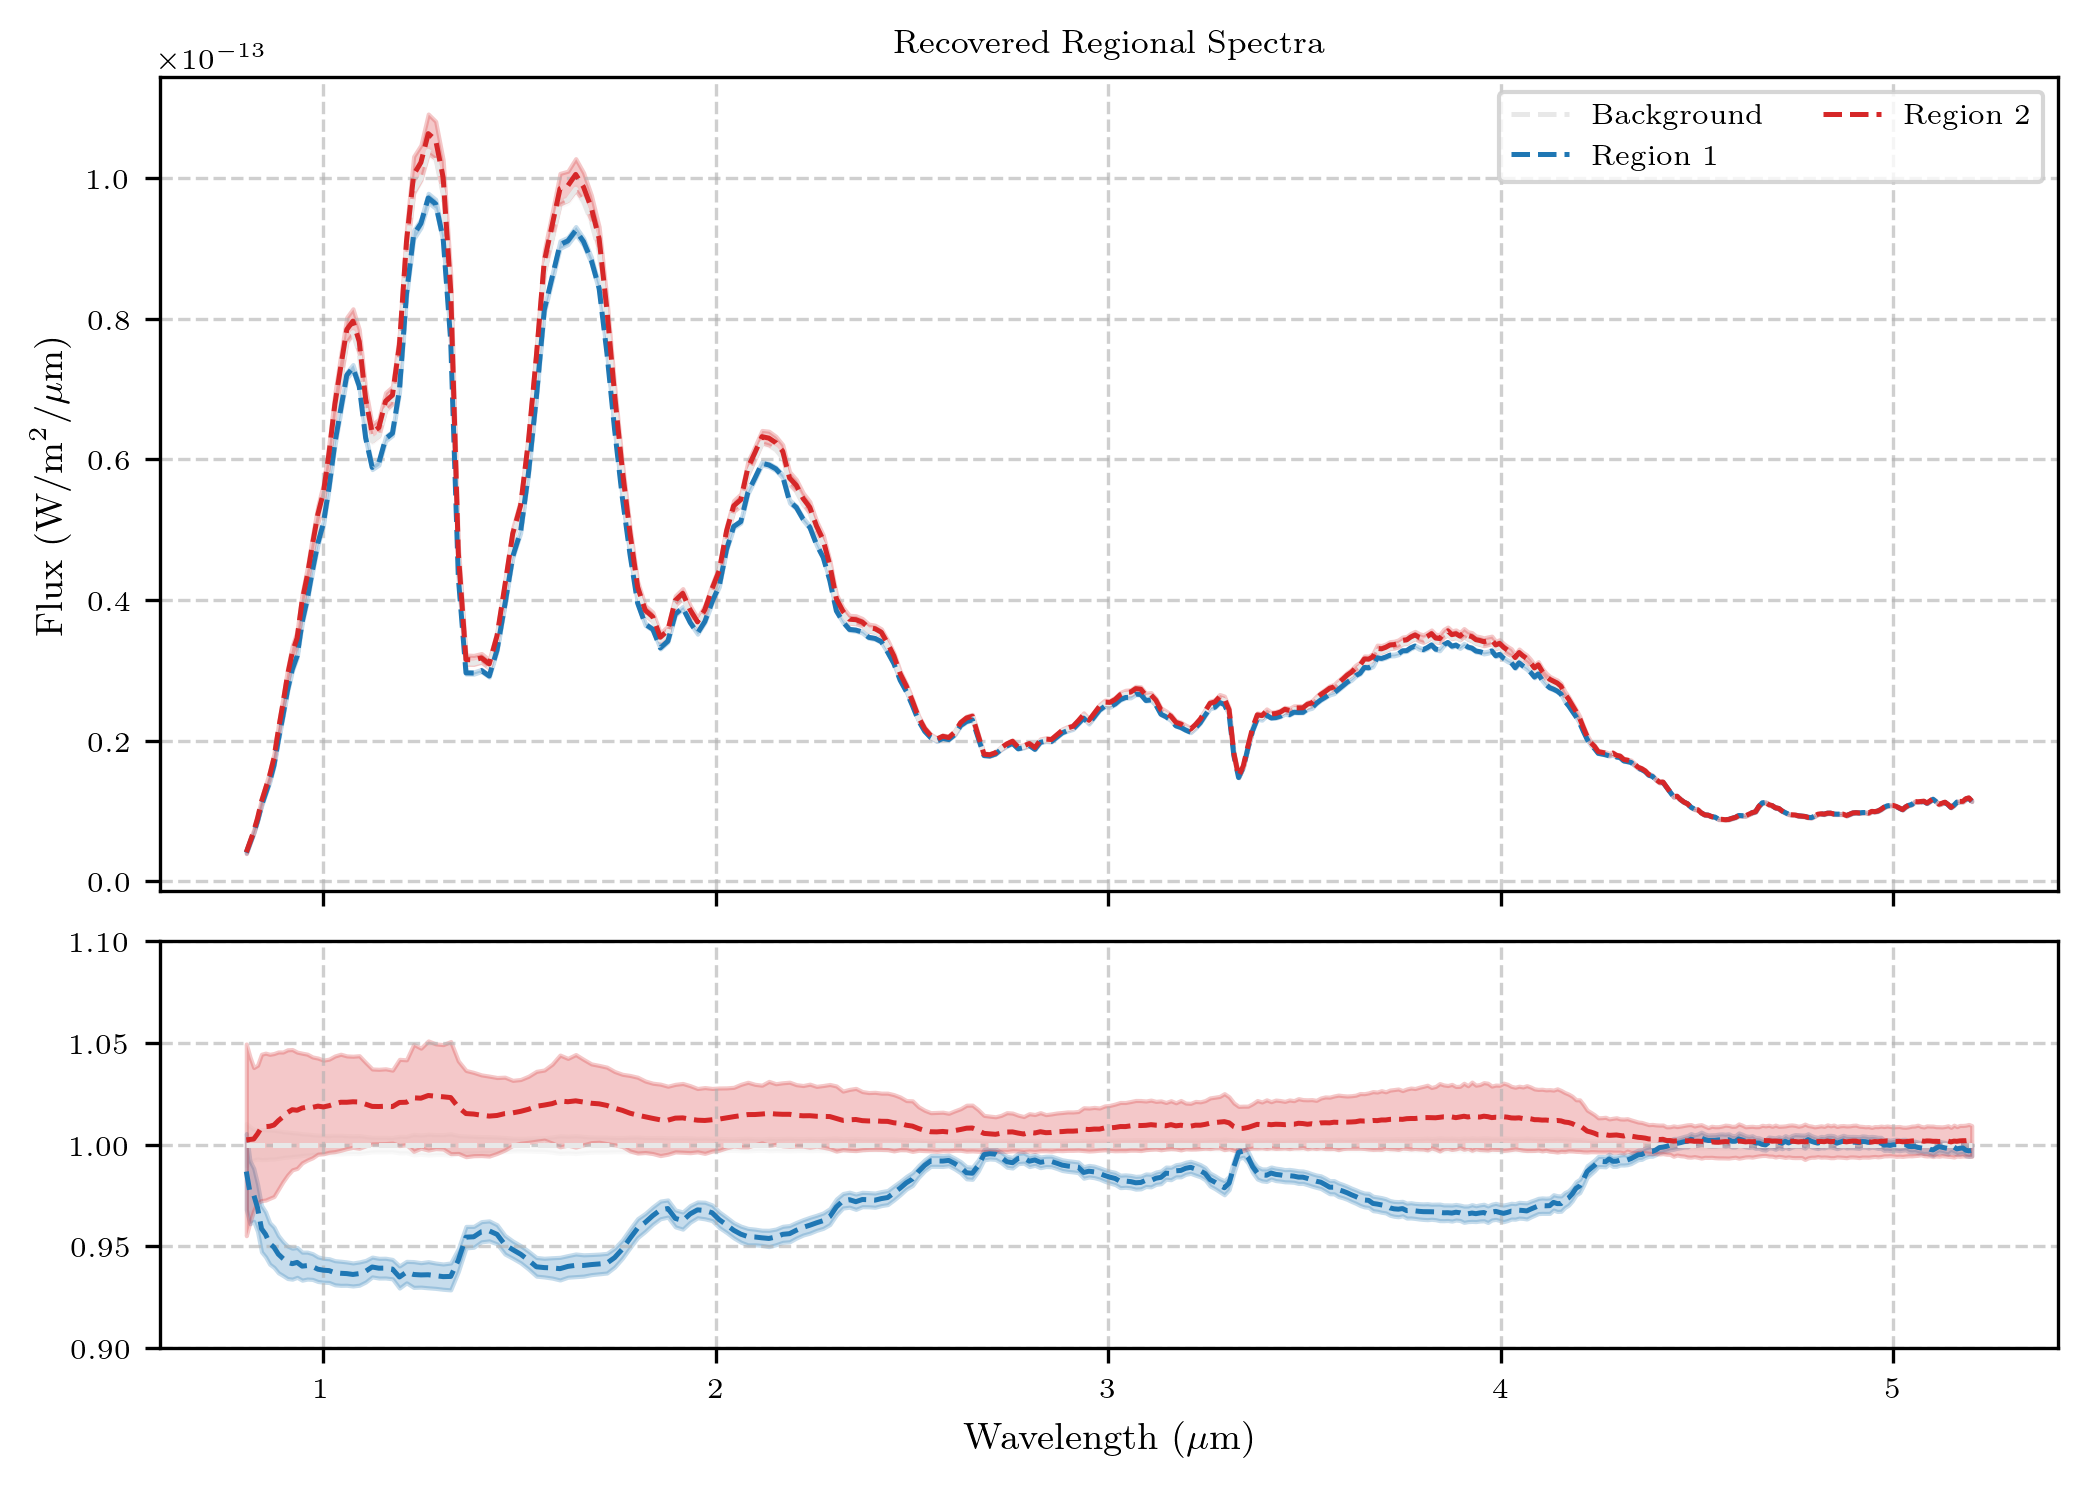

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import xarray as xr

fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

color_list = COLOR_LIST[:N]


F_regionals = F_regionals_24
F_regional_errs = F_regional_errs_24
wl = wl_24

background_flux = F_regionals[0]
background_flux_err = F_regional_errs[0]
# Plot the recovered spectra for each region
for i in range(0, len(F_regionals)):    
    mean_flux = F_regionals[i]
    error_flux = F_regional_errs[i] # Fixed variable name
    color = color_list[i]
    label = cluster_names[i]
    
    axes[0].plot(wl, mean_flux, label=f"{label}", color=color, linewidth=1.2, linestyle='--')
    axes[0].fill_between(wl, 
                         mean_flux - error_flux, 
                         mean_flux + error_flux, 
                         alpha=0.25, color=color)
    axes[1].plot(wl, mean_flux/background_flux, label=f"{label}", color=color, 
                 linewidth=1.2, linestyle='--')
    axes[1].fill_between(wl, 
                         (mean_flux - error_flux)/background_flux,
                         (mean_flux + error_flux)/background_flux, 
                         alpha=0.25, color=color)

# # Overlay the range of the observed time-series variability
# time_series = np.sort(flux_raw.T, axis=0)
# axes[0].fill_between(wl, time_series[0, :],
#             time_series[-1, :], color='black', alpha=0.10, zorder=0, label="Observed Range")

# axes[1].fill_between(wl, time_series[0, :]/background_flux,
#             time_series[-1, :]/background_flux, color='black', alpha=0.10, zorder=0)


# Formatting
axes[1].set_xlabel(r"Wavelength ($\mu$m)", fontsize=9)
axes[0].set_ylabel(r"Flux (W/m$^2$/$\mu$m)", fontsize=9)
axes[0].set_title("Recovered Regional Spectra")
axes[0].legend(loc='upper right', ncol=2)
# axes[0].set_xscale("log")

plt.tight_layout()
axes[1].set_ylim(0.9, 1.1)

output_path = PAPER_FIGURES_DIR + "Luhman16B_recovered_spectra.pdf"
# plt.savefig(output_path, dpi=300, bbox_inches='tight')

-1 600
0 100
1 100
2 100
[0.83852228 0.13322883]


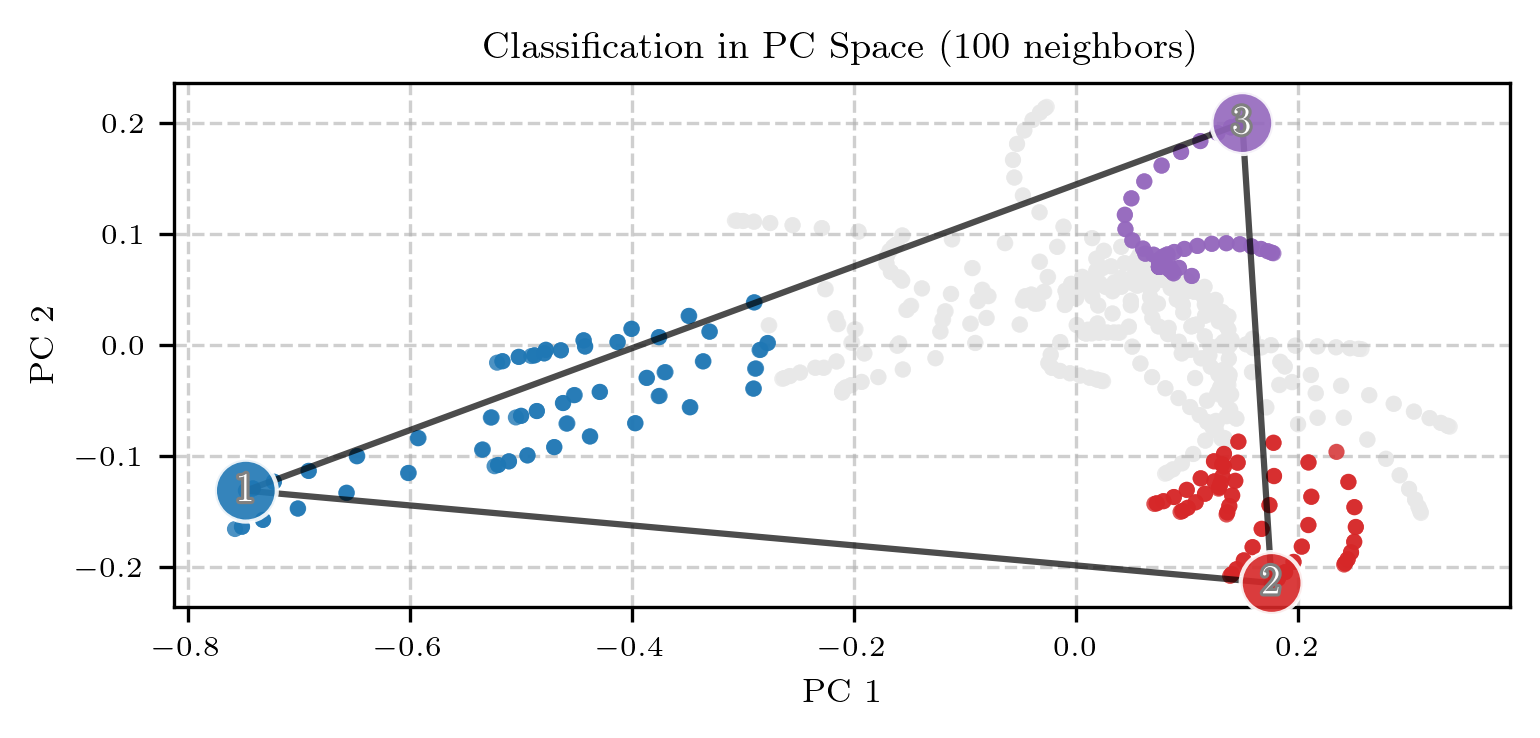

In [53]:
from spectralmap.cluster import find_clusters
F_regionals_23, F_regional_errs_23, labels_23 = find_clusters(F_all_wl_23, F_cov_all_wl_23, n_neighbors=100, n_corners=3)
N = len(F_regionals_23)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit_transform(np.log10(F_all_wl_23).T)
print(pca.explained_variance_ratio_)

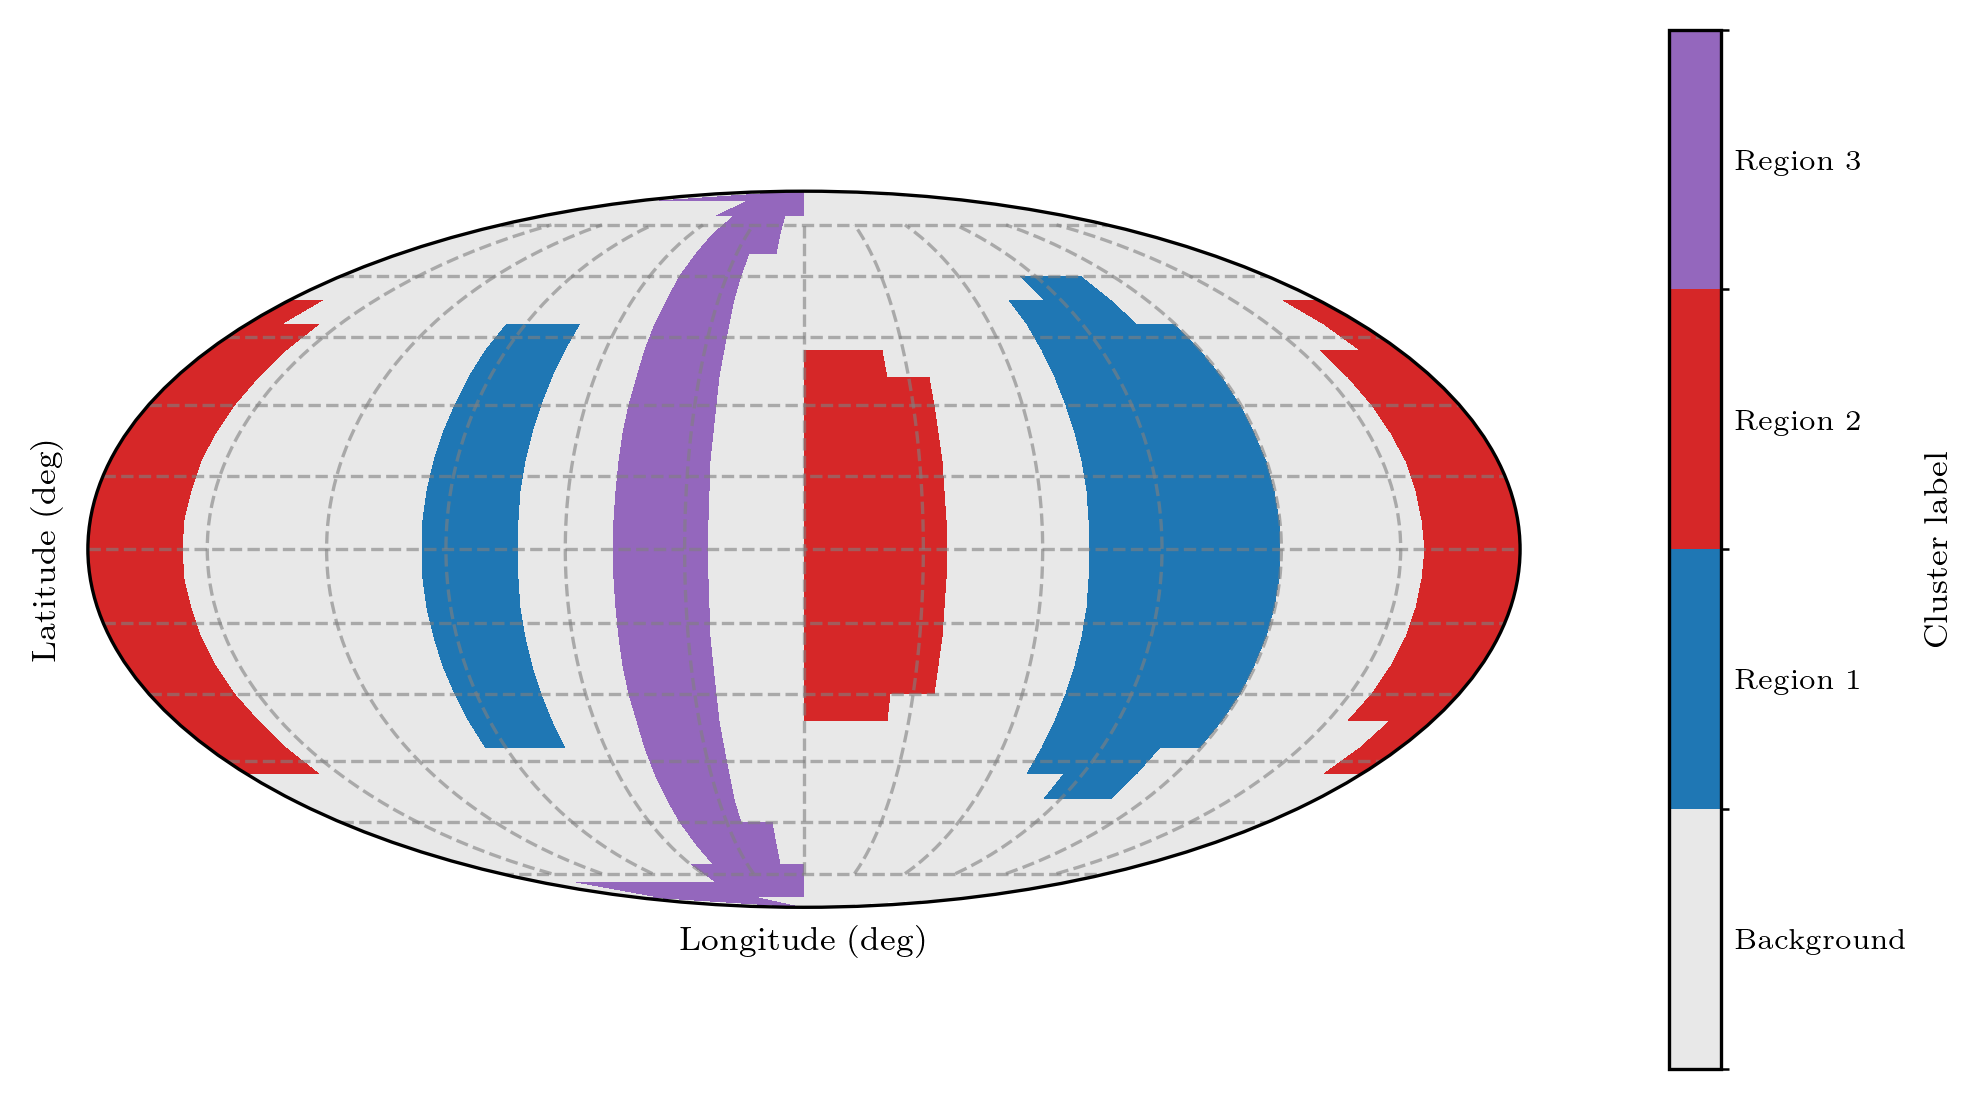

In [54]:
from spectralmap.plotting import plot_mollweide_labels
from matplotlib import colors as mcolors

color_list = COLOR_LIST[:N]
cluster_names = ["Background"] + [f"Region {i+1}" for i in range(N - 1)]
cmap = mcolors.ListedColormap(color_list)

fig, ax, pcm, cb = plot_mollweide_labels(
    labels_masked=labels_23,      # should be ints 0..N-1 on masked pixels
    moll_mask=maps.moll_mask,
    map_res=maps.map_res,
    cmap=cmap,
    names=cluster_names
)

# output_path = PAPER_FIGURES_DIR / "S0136_recovered_regions.pdf"

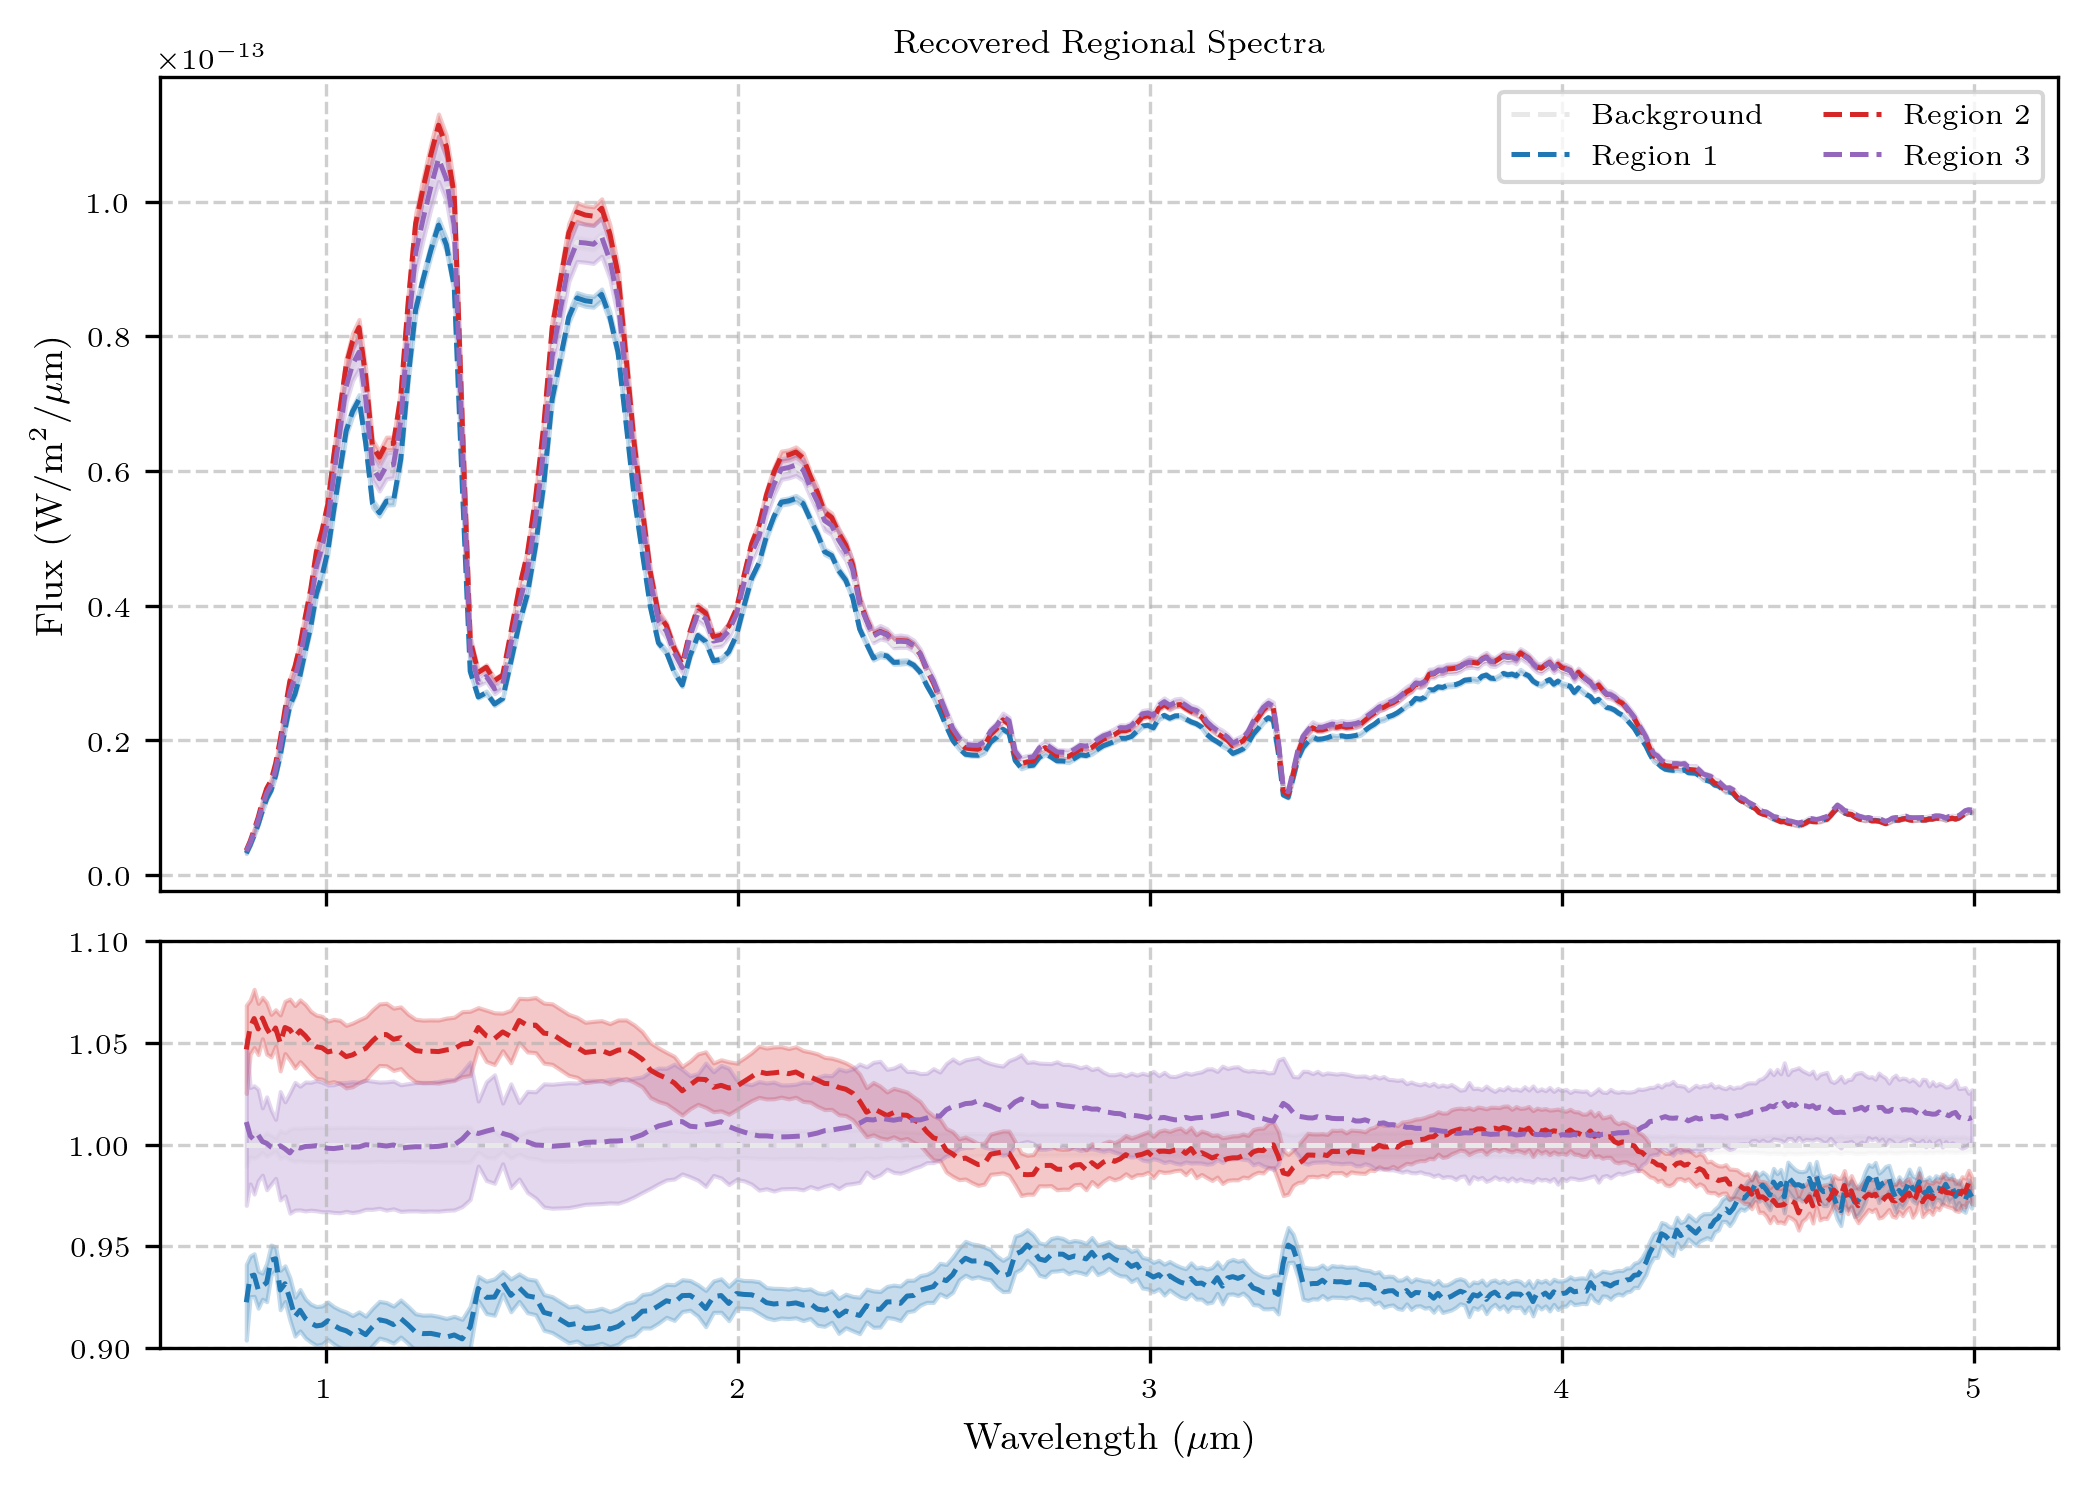

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import xarray as xr

fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

color_list = COLOR_LIST[:N]

F_regionals = F_regionals_23
F_regional_errs = F_regional_errs_23
wl = wl_23

background_flux = F_regionals[0]
background_flux_err = F_regional_errs[0]
# Plot the recovered spectra for each region
for i in range(0, len(F_regionals)):    
    mean_flux = F_regionals[i]
    error_flux = F_regional_errs[i] # Fixed variable name
    color = color_list[i]
    label = cluster_names[i]
    
    axes[0].plot(wl, mean_flux, label=f"{label}", color=color, linewidth=1.2, linestyle='--')
    axes[0].fill_between(wl, 
                         mean_flux - error_flux, 
                         mean_flux + error_flux, 
                         alpha=0.25, color=color)
    axes[1].plot(wl, mean_flux/background_flux, label=f"{label}", color=color, 
                 linewidth=1.2, linestyle='--')
    axes[1].fill_between(wl, 
                         (mean_flux - error_flux)/background_flux,
                         (mean_flux + error_flux)/background_flux, 
                         alpha=0.25, color=color)

# # Overlay the range of the observed time-series variability
# time_series = np.sort(flux_raw.T, axis=0)
# axes[0].fill_between(wl, time_series[0, :],
#             time_series[-1, :], color='black', alpha=0.10, zorder=0, label="Observed Range")

# axes[1].fill_between(wl, time_series[0, :]/background_flux,
#             time_series[-1, :]/background_flux, color='black', alpha=0.10, zorder=0)


# Formatting
axes[1].set_xlabel(r"Wavelength ($\mu$m)", fontsize=9)
axes[0].set_ylabel(r"Flux (W/m$^2$/$\mu$m)", fontsize=9)
axes[0].set_title("Recovered Regional Spectra")
axes[0].legend(loc='upper right', ncol=2)
# axes[0].set_xscale("log")

plt.tight_layout()
axes[1].set_ylim(0.9, 1.1)

output_path = PAPER_FIGURES_DIR + "Luhman16B_recovered_spectra.pdf"
# plt.savefig(output_path, dpi=300, bbox_inches='tight')

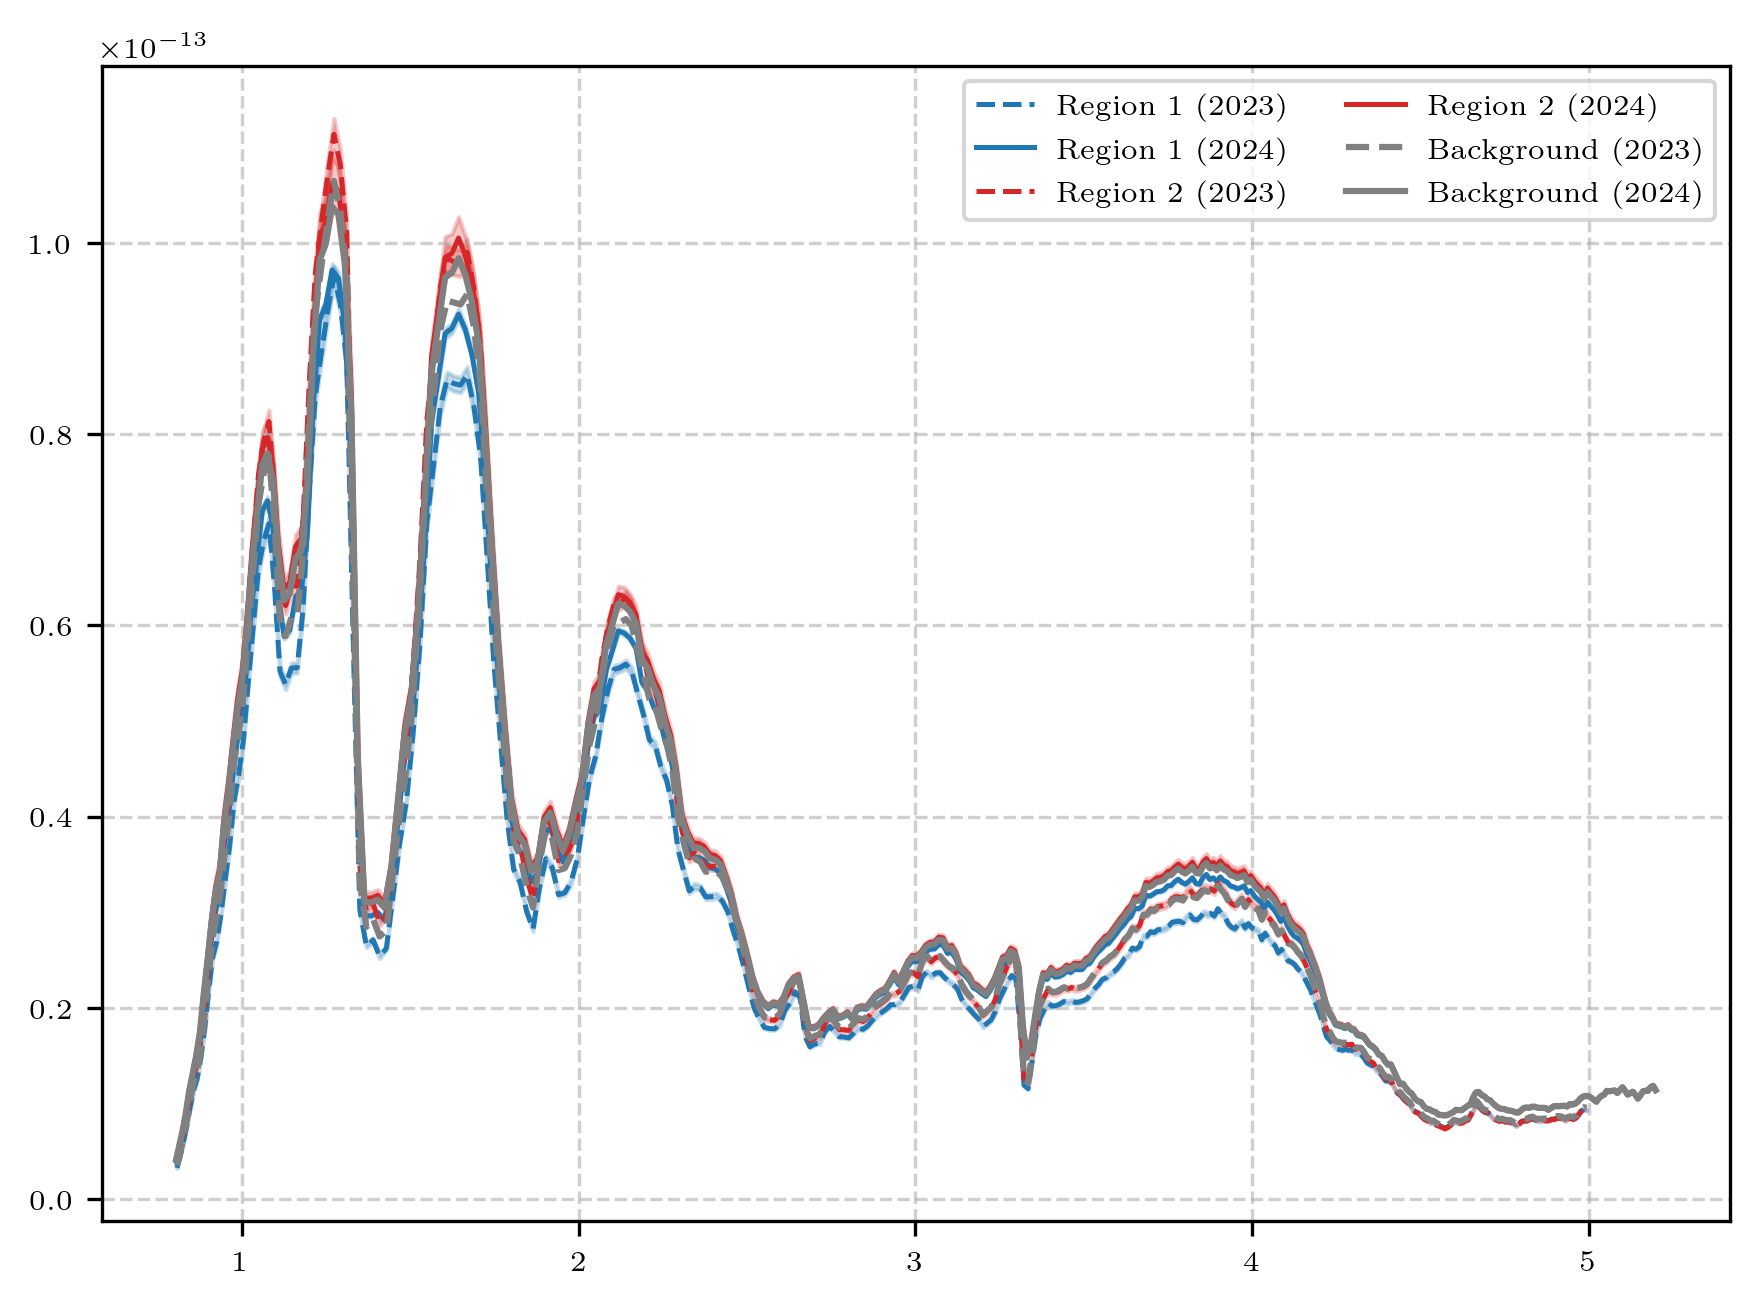

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import xarray as xr

fig, axes = plt.subplots(1, 1, figsize=(7, 5), sharex=True,)

N = 3
color_list = COLOR_LIST

background_flux_24 = F_regionals_24[0]
background_flux_23 = F_regionals_23[0]
# Plot the recovered spectra for each region
for i in range(1, N):
    color = color_list[i]
    label = cluster_names[i]

    if i < len(F_regionals_23):    
        mean_flux_23 = F_regionals_23[i]
        error_flux_23 = F_regional_errs_23[i]    
        axes.plot(wl_23, mean_flux_23, label=f"{label} (2023)", color=color, linewidth=1.2, linestyle='--')
        axes.fill_between(wl_23, 
                             mean_flux_23 - error_flux_23,
                             mean_flux_23 + error_flux_23,
                             alpha=0.25, color=color)

    if i < len(F_regionals_24):
        mean_flux_24 = F_regionals_24[i]
        error_flux_24 = F_regional_errs_24[i] # Fixed variable name
        axes.plot(wl_24, mean_flux_24, label=f"{label} (2024)", color=color, linewidth=1.2, linestyle='-')
        axes.fill_between(wl_24, 
                             mean_flux_24 - error_flux_24, 
                             mean_flux_24 + error_flux_24, 
                             alpha=0.25, color=color)
    
axes.plot(wl_23, background_flux_23, label="Background (2023)", color='gray', linewidth=1.5, linestyle='--')
axes.plot(wl_24, background_flux_24, label="Background (2024)", color='gray', linewidth=1.5, linestyle='-')
# axes.fill_between(wl_24, background_flux_24-F_regional_errs_24[0], background_flux_24+F_regional_errs_24[0], color='gray', alpha=0.10, label="Background Range (2024)")

plt.legend(loc='upper right', ncol=2)